# Load modules

In [1]:
import os
import itk
import cv2
import sys
import json
import glob
import time
import imageio
import slicerio
import numpy as np
import pandas as pd
import nibabel as nib
import pydicom as dcm
from matplotlib import colors
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from lmfit import minimize, Parameters

from urllib.request import urlopen
from datetime import datetime as dtime

# Add the DCMRI (https://dcmri.org/) tools to process/compare DCEMRI quantitative analysis
import dcmri


## Setup fonts for plots
(see [this thread](https://stackoverflow.com/a/39566040))

In [4]:
SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


# Auxiliar Functions
## Utils

In [5]:
def getenv():
    """
    Requires sys and os modules:
    import sys
    import os
    """
    if sys.platform == 'win32':
        env_home = 'HOMEPATH'
    elif (sys.platform == 'darwin') | (sys.platform == 'linux'):
        env_home = 'HOME'
    HOMEPATH = os.getenv(env_home)
    
    return HOMEPATH

def check_path_exist(path, file=False):
    """
    Flag FILE indicates the path contains a file name (FLAG=TRUE) or the path only points to a folder (FLAG=FALSE (Default))
    """
    if file:
        is_path = os.path.isfile(path)
    else:
        is_path = os.path.isdir(path)

    print(f'{"OK:" if is_path else "ERROR:"} Path to {"file" if file else "folder"} {path} does{"" if is_path else " NOT"} exist')

    return is_path

def list_folder(path, skip_patterns=None, sorted=False):
    # Check the path exists:
    if not(os.path.isdir(path)):
        error_message = f'[ERROR]: Folder path {path} does not exist'
        sys.exit(error_message)
    
    raw_list = os.listdir(path)
    
    # Ensure patterns is a list, defaulting to ['.DS_Store']
    dsStorePattern = '.DS_Store'
    if skip_patterns is None:
        skip_patterns = [dsStorePattern]
    elif isinstance(skip_patterns, str):
        skip_patterns = [dsStorePattern, skip_patterns]  # Convert single string to list
    elif isinstance(skip_patterns, (list, tuple, set)):  
        skip_patterns = list(skip_patterns)  # Ensure it's a list
        if dsStorePattern not in skip_patterns:
            skip_patterns.append(dsStorePattern)  # Add default pattern if not already included
    else:
        raise TypeError("patterns must be a string, list, tuple, or set.")

    # dir_list = [item for item in raw_list if skip_pattern not in item]
    # any(p in item for p in skip_patterns) checks if any pattern in skip_patterns exists in item:
    dir_list = [item for item in raw_list if not any(p in item for p in skip_patterns)]

    if sorted:
        dir_list.sort()

    return dir_list


# Function to parse mixed datetime formats
def parse_mixed_datetime(ts, format='%Y%m%d%H%M%S.%f'):
    """
    # Ensure all values have milliseconds (force `.0000` if missing) before the conversion:
    """

    ts_f = ts.apply(lambda x: f"{x}.0000" if pd.notna(x) and "." not in str(x) else x)

    return pd.to_datetime(ts_f, format=format, errors="coerce")

def filter_list(lst, pattern):
    return [item for item in lst if pattern not in item]

def get_list_element(lst, pattern):
    return [item for item in lst if pattern in item]


## Enrst Angles and SPGR equations

In [6]:
def E1(TR, T1):
    
    return np.exp(-TR/T1)

def E2(TE, T2):
    
    return np.exp(-TE/T2)

def fzss(TR, T1, FA_rad):
    
    return (1.0 - E1(TR, T1))/(1.0 - np.cos(FA_rad)*E1(TR, T1))

def s0sinalfa(M0, FA_rad):

    return M0 * np.sin(FA_rad)

def st(M0, T1, TR, FA_rad, TE=np.nan, T2=np.nan):

    stT1 = s0sinalfa(M0, FA_rad) * fzss(TR, T1, FA_rad)
    
    if (np.isnan(T2)) | (np.isnan(TE)):
        return stT1
    else:
        #eq  with t2* decay
        return stT1 * E2(TE,T2)

def ernstAngle(TR, T1):
    # Flip Angle that maximises the signal for a given TR and T1 (REF: Handbook of MRI Pulse Sequences, page 587, Eq. 14.9)
    
    return np.rad2deg(np.arccos(E1(TR, T1)))

def anglesT1Maps(TR,T1):
    # Flip angles for optimal T1 Mapping with only 2 acq (REF: Deoni SCL 2003, Rapid Combined T1 and T2 mapping using..., MRM 49:515-526)
    
    f = 0.71 # see REF
    angle1 = (E1(TR, T1)*np.square(f) + (1-np.square(E1(TR, T1)))*np.sqrt(1-np.square(f)))/(1-(np.square(E1(TR, T1))*(1-np.square(f))))
    angle2 = (E1(TR, T1)*np.square(f) - (1-np.square(E1(TR, T1)))*np.sqrt(1-np.square(f)))/(1-(np.square(E1(TR, T1))*(1-np.square(f))))
    Angles = np.array([angle1,angle2])
    #return Angles
    return np.rad2deg(np.arccos(Angles))


## Helper functions for Linear T1 mapping

In [7]:
# Define a simple atomic function to perform linear fit 
# Add a check before fitting
def safe_polyfit(x, y):
    if np.any(np.isnan(x)) or np.any(np.isnan(y)):
        return np.nan, np.nan
    if np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan, np.nan
    if np.any(x == 0.0) or np.any(y == 0.0):
        return np.nan, np.nan    
    try:
        m, n = np.polyfit(x, y, deg=1)
        return m, n
    except Exception:
        return np.nan, np.nan
    
# Function to apply polyfit to a single pixel across the flip angles
def linfit_pixel(X, Y, i, j, k):
    x_vals = X[:, k, j, i]
    y_vals = Y[:, k, j, i]

    # try:
    mslope, nintercept = safe_polyfit(x_vals, y_vals)
    # except Exception:
    #     mslope = np.nan
    #     nintercept = np.nan

    return (i, j, k, mslope, nintercept)


## Optimisation functions for nonlinear T1 map estimation

In [8]:
# Define cost functions to estimate T1 with SPGR and IR
def fit_SPGR_t1(params, flip_angle_rad, values):
    s0 = params['s0'].value
    t1 = params['t1'].value
    tr = params['tr'].value
    te = params['te'].value
    t2star = params['t2star'].value

    s = st(s0, t1, tr, flip_angle_rad, te, t2star)
    
    return (np.fabs(s) - np.fabs(values))

# Define the optimisation method
def do_spgr_fit(ydata, fa_rad, tr, te=np.nan, t2star=np.nan, initial_s0=1.0, initial_t1=1000.0, T1ub = 10000.0):
    params = Parameters()
    params.add('s0', value=initial_s0, vary=True, min=0.0)
    params.add('t1', value=initial_t1, vary=True, min=0.0, max=T1ub)
    params.add('tr', value=tr, vary=False)
    params.add('te', value=te, vary=False)
    params.add('t2star', value=t2star, vary=False)
    
    result = minimize(fit_SPGR_t1, params, args=(fa_rad, ydata))

    return result    

def safe_nonlinfit(ydata, flipangles_rad, m0, t10, TR, TE, T2star, T1ub):

    if np.any(np.isnan(ydata)):
        print('Some values are NaN')
        return np.nan, np.nan
    
    if np.all(ydata == ydata[0]):
        print('INCONSISTENT DATA: Signal is the same for both Flip Angles')
        return np.nan, np.nan
        
    try:
        nonlin_fit_output = do_spgr_fit(ydata, flipangles_rad, TR, TE, T2star, 
                                        T1ub=T1ub,
                                        initial_s0=m0, initial_t1=t10)
        return nonlin_fit_output.params['t1'].value, nonlin_fit_output.params['s0'].value    

    except Exception:
        return np.nan, np.nan
 
# Function to apply nonlinear fit to a single pixel across the flip angles
def nonlinfit_pixel(Y, FlipAngleRad, T10, TR, T1ub, i, j, k, TE=np.nan, T2star=np.nan):
    ydata = Y[:, k, j, i]

    t1hat, m0hat = safe_nonlinfit(ydata, FlipAngleRad, m0=np.max(ydata), t10=T10, TR=TR, TE=TE, T2star=T2star, T1ub=T1ub)

    return (i, j, k, t1hat, m0hat)


## T1 mapping algorithms

In [9]:
def t1fit_vfa(VFA_listOfImages, VFA_listOfFlipAngles, VFA_parameters, T10=1000.0, FitAlgo='rational_linear', flip_angle_units = 'deg', T1ub=5000.0, T1lb=100.0):
    # Algorithms can be:
    # rational_linear --> Rational Approximation (Helms et al., 2008)
    # std_linear    --> Linear approximation (Gutpa, 1977)
    # non_linear    --> Non-linear ("exact" fitting)

    # List of images must match the length of the flip angles:
    nImages = len(VFA_listOfImages)
    nFlipAngles = len(VFA_listOfFlipAngles)

    if nImages != nFlipAngles:
        print(f'[ERROR]: Length of images {nImages} does not match the list of flip angles {nFlipAngles}')
        sys.exit()

    if nImages < 2:
        print(f'[ERROR]: Not enough images {len(nImages)} to perform the calculations')
        sys.exit()

    # At least we need the TR for the fitting
    if 'TR' not in VFA_parameters.keys():
        print('[ERROR]: Parameter TR is not available, cannot perform the fitting')
        sys.exit()
    
    # If required, convert the flip angles from degree to radians (default behaviour)
    if flip_angle_units == 'deg':
        flip_angles_radians = [np.deg2rad(x) for x in VFA_listOfFlipAngles]
    else:
        flip_angles_radians = VFA_listOfFlipAngles.copy()

    # Call the fitting function 
    if FitAlgo == 'rational_linear':
        if nImages > 2:
            print('[WARNING]: Algorithm {FitAlgo} requires only 2 Flip angles, but {nImages} were provided')
            print(f'Will use only the first 2 flip angles ({flip_angles_radians[:2]})')
            nImages = 2
        T1, M0 = rational_linear_t1_fit(VFA_listOfImages[:nImages], flip_angles_radians[:nImages], VFA_parameters['TR'], T1ub=T1ub, T1lb=T1lb)
    elif FitAlgo == 'std_linear':
        T1 = 0
        M0 = 0
        T1, M0 = standard_linear_t1_fit(VFA_listOfImages[:nImages], flip_angles_radians[:nImages], VFA_parameters['TR'], T1ub=T1ub, T1lb=T1lb)
    elif FitAlgo == 'non_linear' :
        T1 = 0
        M0 = 0
        T1, M0 = nonlinear_t1_fit(VFA_listOfImages[:nImages], flip_angles_radians[:nImages], T10, VFA_parameters['TR'], T1ub=T1ub)
    else:
        print(f'[ERROR]: Method {FitAlgo} is not yet implemented')
        T1 = []
        M0 = []
        sys.exit()
    
    return T1, M0

def rational_linear_t1_fit(VFA_images, VFA_flipangles_rad, TR, T1ub, T1lb):
    
    if 0.0 in VFA_flipangles_rad:
        print('[ERROR]: One of the angles is 0, cannot perform the calculations')
        sys.exit()
    # Find places where signal is the same for both flip angles:
    index_zero_signal = np.nonzero(np.atleast_1d(np.asarray((VFA_images[0]-VFA_images[1]) == 0.0)))

    # if len(index_zero_signal[0]) > 0:
    #     print(f'First: {VFA_images[0][index_zero_signal]}')
    #     print(f'Second: {VFA_images[1][index_zero_signal]}')
    # print(f'Found {len(index_zero_signal[0])} inconsistent pixels')

    Tnum = (VFA_images[0] / VFA_flipangles_rad[0]) - (VFA_images[1] / VFA_flipangles_rad[1]) 
    Tden = (VFA_images[1] * VFA_flipangles_rad[1]) - (VFA_images[0] * VFA_flipangles_rad[0])
    Tden += 1e-6

    T1map = 2.0 * TR * Tnum / Tden
    
    # T1map[np.isnan(T1map)] = 1.0
    if T1map.shape:
        T1map[T1map > T1ub] = np.nan #0.0
        T1map[T1map < T1lb] = np.nan #0.0
        T1map[index_zero_signal] = np.nan #0.0

    Anum = (VFA_flipangles_rad[1]/VFA_flipangles_rad[0] - VFA_flipangles_rad[0]/VFA_flipangles_rad[1])
    Aapp = VFA_images[0] * VFA_images[1] * Anum / Tden
    if Aapp.shape:
        # Aapp[np.isnan(Aapp)] = 0.0
        Aapp[Aapp < 0.0] = np.nan #0.0
        Aapp[index_zero_signal] = np.nan #0.0
    
    return T1map, Aapp

def standard_linear_t1_fit(VFA_images, VFA_flipangles_rad, TR, T1ub, T1lb):

    # Create the xi and yi elements for the X and Y lists (length is the number of flip angles) and 
    # convert it to an np.array for easier manipulation (shape: flipAngle, slices, height, width)
    X = np.array([fa_image/np.tan(fa_value) for fa_image, fa_value in zip(VFA_images, VFA_flipangles_rad)])
    Y = np.array([fa_image/np.sin(fa_value) for fa_image, fa_value in zip(VFA_images, VFA_flipangles_rad)])
    if len(X.shape) == 1:
        X = X[:, np.newaxis, np.newaxis, np.newaxis]
        Y = Y[:, np.newaxis, np.newaxis, np.newaxis]
    elif len(X.shape) == 2:
        X = X[:, :, np.newaxis, np.newaxis]
        Y = Y[:, :, np.newaxis, np.newaxis]
    elif len(X.shape) == 3:
        X = X[:, :, :, np.newaxis]
        Y = Y[:, :, :, np.newaxis]
    
    nFA, nS, nH, nW = X.shape

    # Flatten all pixel coordinates (order seems counter-intuitive, but it is following ITK convention)
    pixel_indices = [(k, j, i) for k in range(nS) for j in range(nH) for i in range(nW)]

    # Run in parallel
    results = Parallel(n_jobs=-1)(delayed(linfit_pixel)(X, Y, i, j, k) for k, j, i in pixel_indices)

    # Reconstruct the output maps (slope and intercepts volumes)
    m = np.zeros((nS, nH, nW))
    n = np.zeros((nS, nH, nW))
    for i, j, k, mijk, nijk in results:
        m[k, j, i] = mijk
        n[k, j, i] = nijk
    
    T1hat = -TR / np.log(m)
    T1hat[np.isnan(T1hat)] = 0.0
    T1hat[T1hat > T1ub] = 0.0
    T1hat[T1hat < T1lb] = 0.0
    
    M0hat = n/(1-m)

    return T1hat, M0hat

def nonlinear_t1_fit(VFA_images, VFA_flipangles_rad, T10, TR, T1ub):
    
    # def nonlinfit_pixel(Y, FlipAngle, i, j, k, TR, TE=None, T2start=None):
    
    # Create the yi elements for the Y list (length is the number of flip angles) and 
    # convert it to an np.array for easier manipulation (shape: flipAngle, slices, height, width)
    Y = np.array(VFA_images)
    if len(Y.shape) == 1:
        Y = Y[:, np.newaxis, np.newaxis, np.newaxis]
    elif len(Y.shape) == 2:
        Y = Y[:, :, np.newaxis, np.newaxis]
    elif len(Y.shape) == 3:
        Y = Y[:, :, :, np.newaxis]

    nFA, nS, nH, nW = Y.shape

    # Flatten all pixel coordinates (order seems counter-intuitive, but it is following ITK convention)
    pixel_indices = [(k, j, i) for k in range(nS) for j in range(nH) for i in range(nW)]

    # Run in parallel
    results = Parallel(n_jobs=-1)(delayed(nonlinfit_pixel)(Y, VFA_flipangles_rad, T10, TR, T1ub, i, j, k) for k, j, i in pixel_indices)

    # Reconstruct the output maps (slope and intercepts volumes)
    T1hat = np.zeros((nS, nH, nW))
    M0hat = np.zeros((nS, nH, nW))

    for i, j, k, t1est, m0est in results:
        T1hat[k, j, i] = t1est
        M0hat[k, j, i] = m0est

    T1hat[np.isnan(T1hat)] = 0.0
    M0hat[np.isnan(M0hat)] = 0.0
    # T1hat[T1hat > T1ub] = 0.0
    # T1hat[T1hat < 0.0] = 0.0

    return T1hat, M0hat


## Pre-processing T1 map

In [10]:
def nt4k_bias_correction(input_itk_volume, simple=False):

    # Cast to float if needed
    input_volume = itk.cast_image_filter(input_itk_volume, ttype=[type(input_itk_volume), itk.Image[itk.F, 3]])

    # Create a mask (you can use the whole image or a thresholded region)
    mask_image = itk.Image[itk.UC, 3].New()
    mask_image.SetRegions(input_volume.GetLargestPossibleRegion())
    mask_image.CopyInformation(input_volume)
    mask_image.Allocate()
    mask_image.FillBuffer(1)  # Whole image as mask

    # Initialize the N4 bias field correction filter
    n4_filter = itk.N4BiasFieldCorrectionImageFilter.New(Input=input_volume, MaskImage=mask_image)

    if not simple:
        # # Set the shrink factor (4 is usually ok)
        n4_filter.SetNumberOfFittingLevels(4)

        # Optionally, set parameters (like number of iterations per level)
        n4_filter.SetMaximumNumberOfIterations([100, 70, 50, 30]) # for an input volume of size [120, 528, 528]

    # Update the filter to perform the correction
    n4_filter.Update()

    # Get the output image
    output_itk_volume = n4_filter.GetOutput()

    return output_itk_volume


In [11]:
def numpy_to_itk(numpy_array, reference_itk_volume):

    # Convert back to ITK image (note: GetArrayFromImage returns z,y,x => shape must match!)
    img_itk = itk.GetImageFromArray(numpy_array)

    # Copy spatial metadata from input_volume_1
    img_itk.SetOrigin(reference_itk_volume.GetOrigin())
    img_itk.SetSpacing(reference_itk_volume.GetSpacing())
    img_itk.SetDirection(reference_itk_volume.GetDirection())

    return img_itk


## AIF

In [12]:
def aif_parker(time_axis, offset=0.0):
    
    tprime = time_axis - offset
    tprime = np.abs( tprime * (tprime >= 0.0) )

    aif_parameters = {
        'A': {'mean': [0.809, 0.330],
            'std': [0.044, 0.040],
            'units': ['mmol.min']*2
            },   
        'T': {'mean': [0.17046, 0.365],
            'std': [0.00073, 0.028],
            'units': ['min']*2
            },
        'SIGMA': {'mean': [0.0563, 0.132],
            'std': [0.0011, 0.021],
            'units': ['min']*2
            },
        'ALFA': {'mean': 1.050,
            'std': 0.017,
            'units': 'mmol'
            },
        'BETA': {'mean': 0.1685,
                'std': 0.0056,
                'units': 'min-1'
                },
        's': {'mean': 38.078,
            'std': 16.78,
            'units': 'min-1'
            },
        'tau': {'mean': 0.483,
            'std': 0.015,
            'units': 'min'
            }            
    }
    
    Cp = aif_parameters['ALFA']['mean'] * np.exp(-aif_parameters['BETA']['mean'] * tprime)
    Cp /= ( 1 + np.exp(-aif_parameters['s']['mean'] * ( tprime - aif_parameters['tau']['mean'] )) )
    for n in range(2):
        An = aif_parameters['A']['mean'][n] / ( aif_parameters['SIGMA']['mean'][n] * np.sqrt(2 * np.pi) )
        arg_exp = - ( (tprime - aif_parameters['T']['mean'][n])**2 ) / ( 2 * (aif_parameters['SIGMA']['mean'][n])**2 )
        Cp += ( An * np.exp(arg_exp) )
    
    Cp *= (tprime > 0.0)

    return Cp
    
    
def aif_wang(time_axis, mode='LD', offset=0.0):
    
    tprime = time_axis - offset
    tprime = np.abs( tprime * (tprime >= 0.0) )
    if mode == 'LD':
        aif_parameters = {
            'Ascale': {'mean': 0.31,
                    'std': 0.14,
                    'cv': 0.44,
                    'units': 'mmol'
                },
            'BETA': {'mean': 0.70,
                        'std': 0.15,
                        'cv': 0.22,
                        'units': 'min-1' 
                        },
            'A': {'mean': [5.84, 0.46],
                        'std': [2.47, 0.24],
                        'cv': [0.42, 0.52],
                        'units': ['']*2 
                },
            'SIGMA': {'mean': [0.09, 0.12],
                        'std': [0.03, 0.08],
                        'cv': [0.38, 0.65],
                        'units':['min']*2 
                },
            'T': {'mean': [0.20, 0.62],
                        'std': [0.08, 0.09],
                        'cv': [0.40, 0.15],
                        'units': ['min']*2 
            },
            'R2': {'mean': 0.95,
                    'std': 0.02,
                    'cv': 0.02,
                    'units': ''
            }
        }
        
        Cp = 1.0
        for n in range(2):
            arg_exp = - ( (tprime - aif_parameters['T']['mean'][n])**2 ) / ( 2 * (aif_parameters['SIGMA']['mean'][n])**2 )
            An = aif_parameters['A']['mean'][n]
            Cp += ( An * np.exp(arg_exp) )
        Cp *= aif_parameters['Ascale']['mean'] * np.log(1 + tprime) * np.exp( -aif_parameters['BETA']['mean'] * tprime )

    elif mode == 'SD':
        aif_parameters = {
            'A': {'mean': 0.36,
                  'std': 0.12,
                  'cv': 0.32,
                  'units': 'mmol'
                  },
            'ALFA': {'mean': 8.93,
                     'std': 5.40,
                     'cv': 0.61,
                     'units': 'min-1'
            },
            'GAMMA': {'mean': 0.61,
                     'std': 0.48,
                     'cv': 0.80,
                     'units': 'min-1'
            },
            'R2': {'mean': 0.93,
                     'std': 0.09,
                     'cv': 0.09,
                     'units': ''
            }                        
        }
        Cp1 = aif_parameters['A']['mean']
        Cp2 = ( 1 - np.exp( -aif_parameters['ALFA']['mean'] * tprime ) )
        Cp3 = ( 1 + np.exp( -aif_parameters['GAMMA']['mean'] * tprime ) )
        Cp = Cp1 * Cp2 * Cp3 * 0.5
        Cp *= (tprime > 0.0)

    return Cp

def pop_based_aif(method, time_axis, offset=0.0, wmode=None):

    if (method=='wang') & (wmode is None):
        print('[WARNING]: Setting MODE to "SD" to use Wang algorithm')
        wmode = 'SD'
    
    if method == 'parker': 
        Cp = aif_parker(time_axis=time_axis, offset=offset)
    elif method == 'wang':
        Cp = aif_wang(time_axis=time_axis, mode=wmode, offset=offset)

    return Cp


## Concentration curves

In [13]:
# Calculating Concentration from Signal Intensity
def ca_conc_chao2017(t10, r1, s0, st, tr, fa):
    ##############################
    # CAREFUL WITH THE UNITS!!!! #
    ##############################
    # 
    # c(t) = A * ( B + log(C / D) )
    # A = -1/(r1*TR)
    # B = TR/T10
    # C = Sratio * fzz - 1
    # D = Sratio * cos(Theta) * fzz - 1
    # Sratio = S(t)/S0
    # fzz = ( 1 - E0 ) / ( 1 - cos(Theta) * E0 )
    # E0 = exp(-TR/T10)

    E0 = E1(tr, t10)
    cosTheta = np.cos(np.deg2rad(fa))
    fzz = (1 - E0) / (1 - cosTheta * E0)
    Sratio = st / s0
    D = Sratio * cosTheta * fzz - 1
    C = Sratio * fzz - 1
    B = tr/t10
    A = -1 / (r1 * tr)

    ct = A * ( B + np.log(C / D) ) 

    return ct


## Dicom Information

In [14]:
def flatten_tags_dictionary(tag_dictionary):
    # TAG_DICTIONARY is a 2-level dictionary
    # The output is a 1-d list containing the 2nd level tags 

    upper_level_tags = tag_dictionary.keys()
    flattened_tags = []
    for ul_tag in upper_level_tags:
        subsetDataLabels = list(tag_dictionary[ul_tag].keys())
        flattened_tags += subsetDataLabels

    # Add the absolute filepath to the dataframe:
    flattened_tags.append('AbsFilePath')

    return flattened_tags


In [15]:
def load_dicom_file(path_to_dicom_file, tags_to_read, read_pixel_tag=False):

    # Reads an individual DICOM file and returns the metadata and image (if required)

    dicom_object = dcm.dcmread(path_to_dicom_file, stop_before_pixels = not(read_pixel_tag))

    dicom_metadata_fields = flatten_tags_dictionary(tags_to_read)
    dicom_metadata = [None]*len(dicom_metadata_fields)

    for tagSubSetName, tagSubSetFields in tags_to_read.items():
        # print(f'TagSubSetName: {tagSubSetName}')
        for tagName, tagValue in tagSubSetFields.items():
            try:
                dicom_metadata[dicom_metadata_fields.index(tagName)] = dicom_object[tagValue['hex']].value
            except Exception:
                # print(f'Attribute {tagName} does not exist, skipping it...')
                pass
    
    # Add the filepath:
    dicom_metadata[dicom_metadata_fields.index('AbsFilePath')] = path_to_dicom_file
    dicom_object = {'metadata': dicom_metadata}

    if read_pixel_tag:
        dicom_object['image'] = dicom_object.pixel_array

    return dicom_object 


In [16]:
def get_dcm_files_recursively(folder_path, file_extension="dcm"):
    """
    Recursively retrieves all DICOM files from a folder and its sub-folders.

    Parameters:
        folder_path (str): The path to the folder to search.
        file_extension (str): The file extension to look for (default is "dcm").

    Returns:
        list: A list of absolute file paths to the DICOM files.

    Example usage:
    folder_path = "/path/to/dicom/folder"
    dcm_files = get_dcm_files_recursively(folder_path)
    print(f"Found {len(dcm_files)} DICOM files.")
    for dcm_file in dcm_files:
        print(dcm_file)
    
    """
    if not os.path.isdir(folder_path):
        raise ValueError(f"The folder path '{folder_path}' does not exist or is not a directory.")

    # Use glob to search recursively for files with the specified extension
    search_pattern = os.path.join(folder_path, f"**/*.{file_extension}")
    dcm_files = glob.glob(search_pattern, recursive=True)

    return dcm_files



In [17]:
def sort_timing_dicom_dataframe(dicom_dataframe):
    # This is the main value added by reading the dicom files by ourselves:
    # Includes time attributes to plot dynamic series

    # Create datetime objects for the paired date and time attributes
    # They must be included as outer keys in TAGS_TO_READ 
    date_time_attr = ['InstanceCreation', 'Study', 'Series', 'Acquisition', 'Content']

    for datetime_tagName in date_time_attr:
        date_attr = datetime_tagName+'Date'
        time_attr = datetime_tagName+'Time'
        dicom_dataframe[datetime_tagName+'DateTime'] = parse_mixed_datetime(dicom_dataframe[date_attr] + dicom_dataframe[time_attr])

    # Additionally, merges the Study Date with Contrast Start/End to ensure they fit in the acquisition window:
    dicom_dataframe['ContrastBolusStartDateTime'] = parse_mixed_datetime(dicom_dataframe['StudyDate'] + dicom_dataframe['ContrastBolusStartTime'])
    dicom_dataframe['ContrastBolusEndDateTime'] = parse_mixed_datetime(dicom_dataframe['StudyDate'] + dicom_dataframe['ContrastBolusStopTime'])

    # Ensures PatientName is a string:
    dicom_dataframe['PatientName'] = dicom_dataframe['PatientName'].astype(str)

    # # Setup a per-slice timing:
    # # For each Series do the following:
    # #   - Sort, in ascending order, the TemporalPositionIdentifier
    # #   - Sort, in ascending order, the slice location (from - to +)
    # #   - Based on the dataframe index, loop over the Temporal position and populate the new field AcquisitionDateTimeSlice:
    # # 
    dicom_dataframe['perSliceAcquisitionTime'] = [None]*len(dicom_dataframe)
    dicom_dataframe['perSliceAcquisitionTimeInSecs'] = [None]*len(dicom_dataframe)
    dicom_dataframe['ContrastBolusStartTimeInSecs'] = [None]*len(dicom_dataframe)

    # Patient List:
    patientList = dicom_dataframe['PatientName'].unique().tolist()
    for patient in patientList:
        # Studies List for each patient:
        patient_in_df = dicom_dataframe[dicom_dataframe['PatientName'].isin([patient])]
        studies_in_patient = patient_in_df['StudyDate'].unique().tolist()
        for study_patient in studies_in_patient:
            study_in_patient = patient_in_df[patient_in_df['StudyDate'].isin([study_patient])]
            sequences_in_study = study_in_patient['SeriesDescription'].unique().tolist()
            # min acquisition time between Dyn eTHRIVE and 4D_THRIVE:
            df_aux = study_in_patient[(study_in_patient['SeriesDescription'].str.startswith('4D_THRIVE')) | (study_in_patient['SeriesDescription'].str.startswith('Dyn'))]
            min_time = df_aux['AcquisitionDateTime'].min(skipna=True)
            for sequence_study_patient in sequences_in_study:
                # We're now at the level of series.
                # For the timming, we're only interested in 4D_THRIVE_Ultrafast & Dyn eTHRIVE:
                if sequence_study_patient.startswith('4D_THRIVE') | sequence_study_patient.startswith('Dyn'):
                    serie_in_study = study_in_patient[study_in_patient['SeriesDescription'].isin([sequence_study_patient])]
                    # Additional Filter to remove the corrupted single file:
                    serie_in_study = serie_in_study[serie_in_study['AcquisitionNumber'].notna()]
                    # Now, we should be ready to assign the timings:
                    # Sort by temporal position:
                    serie_in_study.sort_values(by=['TemporalPositionIdentifier', 'SliceLocation'], ascending=(True, False), inplace=True)
                    nslices = len(serie_in_study['SliceLocation'].unique().tolist())
                    slice_order = range(0, nslices)
                    # Here loop over TimePos and slice location using the formula:
                    # AcquisitionTime  + TR * TempPos * Range(Slice)
                    TR = serie_in_study['RepetitionTime'].unique().tolist()
                    if len(TR) > 1:
                        print(f'WARNING!: There are more than 1 TR ({TR}) in the series. Using the first one available')
                    # else:
                        # print(f'TR: {TR[0]}ms')
                    TR = TR[0]

                    nt = serie_in_study['NumberOfTemporalPositions'].unique().tolist()
                    if len(nt) > 1:
                        print(f'ERROR: The number of temporal positions {nt} is not consistent through the series')
                        sys.exit()
                    # else:
                        # print(f'Number of Temporal Positions: {nt[0]}')                
                    nt = int(nt[0])
                    slices_positions = list(slice_order)*nt
                    perSliceAcquisitionDateTime = pd.to_timedelta([z*TR/1000.0 for z in slices_positions], unit='s')
                    # serie_in_study['perSliceAcquisitionDateTime'] = [None]*len(serie_in_study)
                    serie_in_study['perSliceAcquisitionDateTime'] = serie_in_study['AcquisitionDateTime'] + perSliceAcquisitionDateTime
                    
                    # Find the earliest AcquisitionEndTime (ignoring NaT values) -- But the min time in my case, is the start of the Dyn eTHRIVE acquisition
                    # min_time = serie_in_study['perSliceAcquisitionDateTime'].min(skipna=True)
                    # Compute time differences in seconds for the acquisition and contrast bolus
                    serie_in_study['perSliceAcquisitionTimeInSecs'] = (serie_in_study['perSliceAcquisitionDateTime'] - min_time).dt.total_seconds()
                    serie_in_study['ContrastBolusStartTimeInSecs'] = (serie_in_study['ContrastBolusStartDateTime'] - min_time).dt.total_seconds()

                    dicom_dataframe.loc[serie_in_study.index, 'perSliceAcquisitionDateTime'] = serie_in_study['perSliceAcquisitionDateTime']
                    dicom_dataframe.loc[serie_in_study.index, 'perSliceAcquisitionTimeInSecs'] = serie_in_study['perSliceAcquisitionTimeInSecs']
                    dicom_dataframe.loc[serie_in_study.index, 'ContrastBolusStartTimeInSecs'] = serie_in_study['ContrastBolusStartTimeInSecs']
                    
    # Add time axis in minutes too:
    dicom_dataframe[['perSliceAcquisitionTimeInMins', 'ContrastBolusStartTimeInMins']] = dicom_dataframe[['perSliceAcquisitionTimeInSecs', 'ContrastBolusStartTimeInSecs']]/60.0

    # Slicer3D uses the image position patient coordinate, rather than SliceLocation:
    dicom_dataframe[['x','y','z']] = dicom_dataframe['ImagePositionPatient'].apply(pd.Series)
    
    return dicom_dataframe



## Data Loader Helper

In [18]:
def get_image_dataset(dataset_df, use_philips_rescale=True, debugMode=False):
    """ 
    This function loads the image corresponding a single dataset. 
    I define a single dataset as a set of dicom files within a single sequence (i.e. SeriesDescription is a single value) 
    It requires the image's height and width are the same for all the elements in the dataset. 
    It should be able to deal with 3D (volumetric) and dynamic (time) series, either 2D+time or 4D (3D + time)

    Args:
        dataset_df (_type_): _description_
        use_philips_rescale (bool, optional): _description_. Defaults to True.

    Returns:
        _type_: _description_
    """
    # Ensure the dataset is a single dataset:
    patient_name = dataset_df['PatientID'].unique().tolist()
    if len(patient_name) > 1:
        print(f'WARNING: The dataset contains more than one patient ({patient_name}), check the input')
        sys.exit()
    patientID = patient_name[0]

    scan_date = dataset_df['StudyDate'].unique().tolist()
    if len(scan_date) > 1:
        print(f'WARNING: The dataset contains more than one study date ({scan_date}), check the input')
        sys.exit()
    scan_date = scan_date[0]

    sequence_name = dataset_df['SeriesDescription'].unique().tolist()
    if len(sequence_name) > 1:
        print(f'WARNING: The dataset contains more than one sequence ({sequence_name}), check the input')
        sys.exit()
    sequence_name = sequence_name[0]

    # Rows and Columns must be the same for the whole series:
    nrows_list = dataset_df['Rows'].unique()
    ncols_list = dataset_df['Columns'].unique()
    if (len(nrows_list) > 1) | (len(ncols_list)>1):
        print(f'WARNING: Either the number of ROWS ({nrows_list}) or COLUMNS ({ncols_list}) is not consistent for the Series')
    [w, h] = [ncols_list[0], nrows_list[0]]

    slice_locations = dataset_df['z'].unique().tolist()
    slice_locations.sort(reverse=False)
    
    ns = len(slice_locations)

    number_of_temporal_positions = dataset_df['NumberOfTemporalPositions'].unique()
    # numberOfTempPositions must be only 1 element length, because it must be the same for a single Series (afaik)
    temporal_positions = dataset_df['TemporalPositionIdentifier'].unique().tolist()
    temporal_positions.sort(reverse=False)

    
    if len(number_of_temporal_positions) > 1:
        print(f'WARNING: Check you are processing only one series, the length of temporal_positions is {len(number_of_temporal_positions)}')
        sys.exit()
    nt = number_of_temporal_positions[0]

    if debugMode:
        print(f'Dataset {patientID}-{scan_date}-{sequence_name} contains {ns} slices and {nt} temporal positions of size {w}x{h} (WxH)')

    # Image resolution and slice spacing
    # df_metadata_patient_visit_sequence['PixelSpacing']
    [resRows, resCols]= dataset_df['PixelSpacing'].apply(pd.Series).T.values.tolist()
    deltaRow, deltaCol = [np.unique(resRows), np.unique(resCols)]

    # resolution along the slice direction:
    # delta_z = dataset_df['SliceThickness'].unique()
    delta_z = dataset_df['SpacingBetweenSlices'].unique()

    if (len(deltaRow) > 1) | (len(deltaCol) > 1) | (len(delta_z) > 1):
        print('WARNING: Check you are processing only one series')
        print(f'\t the length of the resolutions parameters is not 1 for Rows ({len(deltaRow)}), Columns ({len(deltaCol)}) and/or slice ({len(delta_z)})')
        sys.exit()

    resx_W, resy_H, resz_Z = [deltaRow[0], deltaCol[0], delta_z[0]]
    if debugMode:
        print(f'Image resolution is {resx_W:.3f}x{resy_H:.3f}x{resz_Z:.2f} [mm/pixel] (WxHxZ)')


    # Load the data, remember the dataframe is already sorted by slice->time:
    # Remember the array order in numpy is W(rows), H(cols), Z(slice)
    image4D = np.full((nt, ns, w, h), np.nan)
    timeaxis_spatial_temporal = np.full((ns, nt), np.nan)
    zlocation_spatial_temporal = np.full((ns, nt), np.nan)

    for dicom_file_row, dicom_datafile in dataset_df.iterrows():
        dcm_object = dcm.dcmread(dicom_datafile['AbsFilePath'])
        slice_position = slice_locations.index(dicom_datafile["z"])
        time_position = temporal_positions.index(dicom_datafile["TemporalPositionIdentifier"])
        # print(f'Slice Position: {slice_position}')
        # print(f'Temporal Position: {time_position}')
        
        dcm_image_32bit = dcm_object.pixel_array.astype(np.float32)
        # if rescale:
        # According to this thread https://stackoverflow.com/questions/67889762/what-is-the-difference-between-rescale-slope-intercept-and-scale-slope-inter
        # The forumalea relevant are:
        # D = R * RS + RI; R= raw pixel value, RS Rescale Slope (0028,1053), RI Rescale Intercept (0028,1052)
        # P = D / (RS * SS); D= Displayed Value (in the scanner screen), RS Rescale Slope (0028,1053), SS Scale Slope (2005,100E) "PhilipsScaleSlope"
        dcm_image_32bit *= dicom_datafile['RescaleSlope']
        dcm_image_32bit += dicom_datafile['RescaleIntercept']
        if use_philips_rescale:
            dcm_image_32bit /= (dicom_datafile['RescaleSlope'] * dicom_datafile['PhilipsScaleSlope'])

        # image4D[:,:,slice_position, time_position] = dcm_image_32bit
        image4D[time_position, slice_position, :, :] = dcm_image_32bit
        # Get the timing (secs) and location (mm) of each slice, in secs. It allows to easily get the time axis when plotting the data
        timeaxis_spatial_temporal[slice_position, time_position] = dicom_datafile['perSliceAcquisitionTimeInSecs']
        zlocation_spatial_temporal[slice_position, time_position] = dicom_datafile['z']
    

    image4D = np.squeeze(image4D)
    scanDetails = {'scanDateTime': scan_date,
                   'sequenceName': sequence_name,
                   'spacing': [resx_W, resy_H, resz_Z],
                   'ImageOrientationPatient': dataset_df['ImageOrientationPatient'],
                   'ImagePositionPatient': dataset_df['ImagePositionPatient'],
                   'TR': dataset_df['RepetitionTime'].unique().tolist(),
                   'TE': dataset_df['EchoTime'].unique().tolist(),
                   'FA': dataset_df['FlipAngle'].unique().tolist(),
                   'ETL': dataset_df['EchoTrainLength'].unique().tolist()
                   }

    return image4D, zlocation_spatial_temporal, timeaxis_spatial_temporal, scanDetails


In [19]:
# Loop over a folder with DICOM files (they may be inside subfolders too) and create a dataframe with the metadata of all the dicom files identified
def load_dicom_folder(path_to_dicom_folder, tags_to_read, fext='dcm', read_pixel_tag=False):
    # Reads a folder with DICOM files and returns a dataframe with the metadata and images (if required)
    # check the folder recursiverly for DICOM files
    dcmlist = get_dcm_files_recursively(path_to_dicom_folder, fext)
    print(f'There are {len(dcmlist)} files in {path_to_dicom_folder}')    

    dicom_metadata_hdr = flatten_tags_dictionary(tags_to_read)
    dicomMetadataList = []
    for dcmfile in dcmlist:
        dcm_metadata = load_dicom_file(dcmfile, tags_to_read, read_pixel_tag)
        dicomMetadataList.append(dcm_metadata['metadata'])

    dicom_dataframe = pd.DataFrame(columns=dicom_metadata_hdr, data=dicomMetadataList)#.astype(dtype_df_dict)

    dicom_dataframe = sort_timing_dicom_dataframe(dicom_dataframe)
    
    return dicom_dataframe


In [20]:
def load_patient_data(df_metadata, patient_id, sequence_patterns, usePhilipsReScale, debugMode=False):

    # Filter the main dataframe to get the patient of interest:
    patient_in_df = df_metadata[df_metadata['PatientID'].isin([patient_id])]
    # StudyID
    study_id = patient_in_df["StudyID"].unique().tolist()
    if len(study_id) > 1:
        print(f'[WARNING]: The StudyID for patient {patient_id} is not unique {study_id} ')
    study_id = study_id[0]
    # For the selected patient, gets the study dates. There are up to 2 visits per patient, the earliest must be the visit 1:
    visits_dates = sorted(patient_in_df['StudyDate'].unique().tolist())
    if len(visits_dates) > 2:
        print(f'[WARNING]: There are more than 2 visits for patient {patient_id}. Considering only the earlier two')
        visits_dates = visits_dates[:2]
    visits_id = dict(zip([1, 2],visits_dates))

    patient_data = {'StudyID': study_id,
                    'Visits': {}}
    for visit_idx, visit_date in visits_id.items():
        visit_df = patient_in_df[patient_in_df['StudyDate'].isin([visit_date])]
        patient_data['Visits'][visit_idx] = {
            'VisitID': visit_date,
            'Date': dtime.strptime(visit_date, "%Y%m%d"),
            'Sequences': dict([(sequence,{}) for sequence in sequence_patterns])
            }
        # Load the imaging data for each sequence
        for sequence_pattern in sequence_patterns:
            sequence_df = visit_df[visit_df['AbsFilePath'].str.contains(sequence_pattern)]
            image_array, image_itk, image_parameters = load_imaging_data(sequence_df, usePhilipsReScale, debugMode=debugMode)
            patient_data['Visits'][visit_idx]['Sequences'][sequence_pattern]['itk'] = image_itk
            patient_data['Visits'][visit_idx]['Sequences'][sequence_pattern]['nparray'] = image_array
            patient_data['Visits'][visit_idx]['Sequences'][sequence_pattern]['metadata'] = image_parameters
    
    return patient_data
    

def load_imaging_data(sequence_df, usePhilipsReScale, debugMode=False):
    # Get parameters of interest: SequenceID, TR, FA
    imaging_parameters = {
        'sequenceID': sequence_df['AbsFilePath'].apply(os.path.dirname).unique().tolist()[0]
    }

    flip_angle = sequence_df['FlipAngle'].unique().tolist()
    if len(flip_angle) > 1:
        print(f'[WARNING]: The dataset contains more than one flip angle ({flip_angle}), check the input')
        sys.exit()
    imaging_parameters['FA'] = flip_angle[0]

    rep_time = sequence_df['RepetitionTime'].unique().tolist()
    if len(rep_time) > 1:
        print(f'[WARNING]: The dataset contains more than one TR ({rep_time}), check the input')
        sys.exit()
    imaging_parameters['TR'] = rep_time[0]

    volume_array, slice_position_matrix, time_matrix, scan_details = get_image_dataset(sequence_df, use_philips_rescale=usePhilipsReScale, debugMode=debugMode)
    volume_itk, volume_metadata = create_itk_from_dicom(volume_array, scan_details, time_matrix, debugMode=debugMode)
    
    imaging_parameters['SliceMatrix'] = slice_position_matrix
    imaging_parameters['TimeMatrix'] = time_matrix
    imaging_parameters['ScanDetails'] = scan_details
    imaging_parameters['ITKMetadata'] = volume_metadata
    
    return volume_array, volume_itk, imaging_parameters

def create_itk_from_dicom(volume_asarray, subset_dicom_metadata, time_matrix, debugMode=False):
    # Identify whether the data is 3D or 4D:
    ndims = np.ndim(volume_asarray)
    eye = np.eye(ndims)
    
    eye[:3, :2] = np.array(subset_dicom_metadata['ImageOrientationPatient'].values[0]).reshape(2,3).T

    direction_matrix = itk.matrix_from_array(eye)

    # The DICOM convention is (x,y,z), but ITK's convention is (z, y, x)
    origin_vector = np.array(subset_dicom_metadata['ImagePositionPatient'].apply(pd.Series).min())
    spacing_vector = np.array(subset_dicom_metadata['spacing'])
    if ndims == 4:
        volume_as_list = np.split(volume_asarray, volume_asarray.shape[0], axis=0)

        itk_volume = itk.compose_image_filter(*volume_as_list)
        dyn_mode, c = np.unique(np.diff(time_matrix[1,:]), return_counts=True)
        time_spacing = dyn_mode[np.argmax(c)]
        spacing_vector = np.insert(spacing_vector, 0, time_spacing)
        origin_vector = np.insert(origin_vector, 0, 0)
    else:
        itk_volume = itk.GetImageFromArray(volume_asarray)    
    if debugMode:
        print(f'Volume size: {itk_volume.shape}')
    itk_volume.SetSpacing(spacing_vector)
    itk_volume.SetOrigin(origin_vector)
    itk_volume.SetDirection(direction_matrix)
 
    itk_volume_metada = dict(itk_volume)
    if debugMode:
        print(f'Metadata: {itk_volume_metada}')
    return itk_volume, itk_volume_metada


In [21]:
dicom_dictionary = {
'ID': { # Patient and Study ID
            'StudyID': {'hex': 0x00200010,
                         #  'type': str
                         },
            'PatientName': {'hex': 0x00100010,
                         #    'type': str
                            },
            'PatientID': {'hex': 0x00100020,
                         #  'type': str
                         }
     },
'SeriesID': { # Acquisitions and Series ID
            'SeriesDescription': {'hex': 0x0008103e,
                         #  'type': str
                         },
            'SeriesNumber': {'hex': 0x00200011,
                         #  'type': pd.Int64Dtype()
                         },
            'AcquisitionNumber': {'hex': 0x00200012,
                              #     'type': pd.Int64Dtype()
                                  },
            'InstanceNumber':{'hex': 0x00200013,
                              # 'type': pd.Int64Dtype()
                             }
            # 'ImagesInAcquisition': {'hex': 0x00201002,
            #                   #     'type': pd.Int64Dtype()
            #                       }
          },
'DatesTimes': { #  Dates & Times
            'StudyDate': {'hex': 0x00080020,
                         #  'type': str
                         },
            'StudyTime': {'hex': 0x00080030,
                         #  'type': str
                         },
            'SeriesDate': {'hex': 0x00080021,
                         #  'type': str
                         },
            'SeriesTime': {'hex': 0x00080031,
                         #  'type': str
                         },
            'AcquisitionDate': {'hex': 0x00080022,
                         #  'type': str
                         },
            'AcquisitionTime': {'hex': 0x00080032,
                         #  'type': str
                         },
          #   'AcquisitionDateTime': {'hex': 0x0008002A,
          #                          'type': str
          #                },
            'AcquisitionDuration': {'hex': 0x00189073, # Duration of the single continuous gathering of data over a period of time that resulted in this instance, in seconds.
                                   #  'type': pd.Float64Dtype()
                                    },
            'ContentDate': {'hex': 0x00080023,
                         #  'type': str
                         },
            'ContentTime': {'hex': 0x00080033,
                         #    'type': str
                            },
            'InstanceCreationDate': {'hex': 0x00080012,
                         #  'type': str
                         },
            'InstanceCreationTime': {'hex': 0x00080013,
                         #  'type': str
                         },
            'PerformedProcedureStepEndDate': {'hex': 0x00400250,
                         #  'type': str
                         },
            'PerformedProcedureStepEndTime': {'hex': 0x00400251,
                         #  'type': str
                         }
          },
'AcqPars': { # Acquisition Parameters
            'ImageType': {'hex': 0x00080008,
                        #   'type': 
                        },
            'ScanningSequence': {'hex': 0x00180020,
                                 },
            'SequenceVariant': {'hex': 0x00180021,
                                 },
            'ScanOptions': {'hex': 0x00180022, # Parameters of scanning sequence.
                         #    'type': str
                            },
            'MRAcquisitionType': {'hex': 0x00180023,
                              #     'type': str
                                  },
            'SequenceName': {'hex': 0x00180024, 
                         #    'type': str
                            },
            'RepetitionTime': {'hex': 0x00180080,
                              #  'type': pd.Float64Dtype()
                               },
            'EchoTime': {'hex': 0x00180081,
                         # 'type': pd.Float64Dtype()
                         },
            'FlipAngle': {'hex': 0x00181314,
                         #  'type': pd.Float64Dtype()
                          },
            'InversionTime': {'hex': 0x00180082,
                              # 'type': pd.Float64Dtype()
                         },
            'NumberOfAverages': {'hex': 0x00180083,
                              # 'type': pd.Int64Dtype()
                         },
            'NumberOfPhaseEncodingSteps': {'hex': 0x00180089,
                                        #    'type': pd.Int64Dtype()
                                           },
            'EchoTrainLength': {'hex': 0x00180091,
                              #   'type': pd.Int64Dtype()
                                },
            'PercentSampling': {'hex': 0x00180093,
                              #   'type': pd.Float64Dtype()
                                },
            'PercentPhaseFieldOfView': {'hex': 0x00180094,
                                        # 'type': pd.Float64Dtype()
                                        },
            'PixelBandwidth': {'hex': 0x00180095,
                              #  'type': pd.Float64Dtype()
                               },
            'TriggerTime': {'hex': 0x00181060, # Time, in msec, between peak of the R wave and the peak of the echo produced
                         #    'type': pd.Float64Dtype()
                            },
            'InPlanePhaseEncodingDirection': {'hex': 0x00181312,
               #   'type': str
                 },
            'TemporalPositionIdentifier': {'hex': 0x00200100,
               #   'type': str
                 },
            'NumberOfTemporalPositions': {'hex': 0x00200105,
                                        #   'type': str
                                          },
            # 'TemporalResolution': {'hex': 0x00200110,
            #                             #   'type': str
            #                               },
            'SliceLocation':{'hex': 0x00201041,
                         #     'type': pd.Float64Dtype()
                            },
            'ImagePositionPatient':{'hex': 0x00200032,
                                   #  'type': object
                                    },
            'SliceThickness': {'hex': 0x00180050,
                              #  'type': pd.Float64Dtype()
                               },
            'SpacingBetweenSlices': {'hex': 0x00180088,
                                   #   'type': pd.Float64Dtype()
                              },
            'ImageOrientationPatient': {'hex': 0x00200037,
                                        # 'type': object
                              },
            'IsoCenterPosition': {'hex': 0x300A012C,
                              }
          },
'ImagePars': { # Reconstruction/Image Parameters
            'AcquisitionMatrix': {'hex': 0x00181310,
                              #     'type': object
                                  },
            'PixelSpacing': {'hex': 0x00280030,
                         #     'type': object
                             },
            'Rows': {'hex': 0x00280010,
                    #  'type': pd.Int64Dtype()
                     },
            'Columns': {'hex': 0x00280011,
                    #     'type': pd.Int64Dtype()
                        },
            # 'PixelAspectRatio': {'hex': 0x00280034,
            #                   #    'type': object
            #                      },
            'ReconstructionDiameter': {'hex': 0x00181100,
                                   #     'type': pd.Float64Dtype()
                                       },
            'RescaleType': {'hex': 0x00281054,
                         #    'type': str
                            },
            'RescaleIntercept': {'hex': 0x00281052, # RI
                         #    'type': pd.Float64Dtype()
                            },
            'RescaleSlope': {'hex': 0x00281053, # RS
                         #    'type': pd.Float64Dtype()
                            },
            # 'PhilipsRWVSlope': {'hex': 0x00409225,  # Philips Private Attribute
            #                   #   'type': pd.Float64Dtype()
            #                    },
            # 'PhilipsRWVIntercept': {'hex': 0x00409224,  # WI, Philips Private Attribute
            #                        #  'type': pd.Float64Dtype()
            #                         },
            'PhilipsScaleSlope': {'hex': 0x2005100E, # SS, Philips Private Attribute
                              #     'type': pd.Float64Dtype()
                                  }
            # 'PhaseNumber': {'hex': 0x20011008, # Philips Private Attribute
            #              #    'type': pd.Int64Dtype()
            #                 }
          },
'ContrastAgent': { # Contrast Agent
            'ContrastBolusAgent': {'hex': 0x00180010,
                         #  'type': str
                         },
            'ContrastBolusRoute': {'hex': 0x00181040,
                         #  'type': str
                         },
            'ContrastBolusVolume': {'hex': 0x00181041,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusStartTime': {'hex': 0x00181042,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusStopTime': {'hex': 0x00181043,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusTotalDose': {'hex': 0x00181044,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastFlowRate': {'hex': 0x00181046,
                         #  'type': pd.Float64Dtype()
                         },
          }
   }


# T1 mapping (VFA method)
SPGR signal equation: 
$$ S(T_1, T_R, \alpha, M_0) = M_0\sin(\alpha)\frac{1 - E_1(T_1,T_R)}{1 - E_1(T_1,T_R)\cos(\alpha)} $$
$$ E_1(T_1, T_R) = \exp(-T_R/T_1) $$

If we acquire multiple flip angles, keeping everything else constant, the equation \ref{spgr} can be linearised and T1 derived from the slope of such line:

$$ \frac{S_i}{\sin(\alpha_i)} = E_1\frac{S_i}{\tan(\alpha_i)} + M_0(1-E_1) $$
$$ \hat{Y}[i] = m\hat{X}[i] + n $$

with: $ \hat{Y}[i] = \frac{S_i}{\sin(\alpha_i)} $; $ \hat{X}[i] = \frac{S_i}{\tan(\alpha_i)} $ ; $ m = E_1 $; $ n = M_0(1-E1) $


As shown by [Helms et al., 2008](https://onlinelibrary.wiley.com/doi/full/10.1002/mrm.21542), derived from the linear approximation, the $T_1$ map can be derived straightforward from the signal intensities and flip angles of the two acquisitions:
$$
\hat{T_1} = 2T_R \frac{\frac{S_1}{\alpha_1} - \frac{S_2}{\alpha_2}}{S_2\alpha_2 - S_1\alpha_1}
$$
$$
\hat{M_0} = S_1S_2 \frac{\frac{\alpha_2}{\alpha_1} - \frac{\alpha_1}{\alpha_2}}{S_2\alpha_2 - S_1\alpha_1}
$$


## Population-based AIF
In this section, an Arterial Input Function is defined by implementing the model proposed by [Parker et al. MRM 56(5): 993-1000; 2006](https://onlinelibrary.wiley.com/doi/full/10.1002/mrm.21066), derived from the fitting of two gaussians distributions and an exponential function modulated with a sigmoid function to the mean AIF measurements of 67 AIFs (see details in the publication cited):

\begin{equation}
AIF_{Parker}(t) = \sum_{n=1}^{2} \frac{A_n}{\sigma_n\sqrt{2\pi}}e^{-\frac{(t - T_n)^{2}}{2\sigma_n^{2}}} + \alpha \frac{e^{-\beta t}}{1 + e^{-s(t-\tau)}}
\end{equation}

with the parameters defined in Table 1 of [Parker et al. MRM 56(5): 993-1000; 2006](https://onlinelibrary.wiley.com/doi/full/10.1002/mrm.21066):

| Parameter |   $A_1$   |   $A_2$   |   $T_1$ | $T_2$  | $\sigma_1$ | $\sigma_2$ | $\alpha$ | $\beta$ |   s	   | $\tau$ |
| --------- | :----:    | :----:    | :----:  | :----: | :----:     | :----:     | :----:   | :----:  | :----: | :----: | 
| Value	    | 0.809	    | 0.330     | 0.17046 | 0.365  | 0.0563     | 0.132      | 1.050    | 0.1685  | 38.078 | 0.483  | 
| SD	    | 0.044	    | 0.040     | 0.00073 | 0.028  | 0.0011     | 0.021      | 0.017    | 0.0056  | 16.78  | 0.015  | 
| Units     | $\text{mmol} \cdot \text{min}$	| $\text{mmol} \cdot \text{min}$	| $\text{min}$	  | $\text{min}$	   | $\text{min}$	    | $\text{min}$        | $\text{mmol}$     | $\text{min}^{-1}$ | $\text{min}^{-1}$ | $\text{min}$    | 

More recently [Wang et al. MRI 34(2): 197-203; 2016](https://www.sciencedirect.com/science/article/abs/pii/S0730725X15002623) proposed the following functional form, with less parameters (8 instead of 10) and such that $C_p(t_{t=0}) = 0$:

\begin{equation}
AIF_{Wang}(t) = A \ln(1 + t) e^{-\beta t} (1 + \sum_{n=1}^{2} A_n e^{-\frac{(t-t_n)^{2}}{2\sigma_n^{2}}})
\end{equation}

with the parameters defined in Table 1 of [Wang et al. MRI 34(2): 197-203; 2016](https://www.sciencedirect.com/science/article/abs/pii/S0730725X15002623):

| Parameter |   $A$   |   $\beta$   |   $A_1$ | $\sigma_1$  | $t_1$   | $A_2$ | $\sigma_2$ | $t_2$  |   $R^{2}$ |
| --------- | :----:  | :----:     | :----:  |   :----:    | :----:  | :----:|  :----:    | :----: | :------: | 
| Value	    |  0.31 | 0.70 | 5.84 | 0.09 | 0.20 | 0.46 | 0.12 | 0.62 | 0.95 | 
| SD	    |  0.14 | 0.15 | 2.47 | 0.03 | 0.08 | 0.24 | 0.08 | 0.09 | 0.02 | 
| CV        |  0.44 | 0.22 | 0.42 | 0.38 | 0.40 | 0.52 | 0.65 | 0.15 | 0.02 |
| Units     | $\text{mmol}$	| $\text{min}^{-1}$	| []  | $\text{min}$ | $\text{min}$ | [] | $\text{min}$ | $\text{min}$ | [] | 


### [$T_1$ and contrast media concentrations](#t1-ca-concentrations)
To simplify the analysis, I'll assume the tissue of interest and the contrast agent are in the fast-exchange regime (ref Yenkeelov et al.), so the relationships are direct and linear. Later on, I'll include sophistications and deviations from this situation. For now, in the fast-exchange regime, the relationship between the shortening of $T_1$ and the contrast agent is given by:
\begin{equation}
\frac{1}{T_1(c(t))} = \frac{1}{T_{10}} + r_1c(t)
\end{equation}
where $c(t)$ is the concentration of contrast agent, that varies over time (e.g. during washin/washout), $T_{10}$ the baseline $T_1$ of the tissue, i.e. the native $T_1$ that depends on the tissue and the main magnetic field, and $r_1$ the relaxivity of the contrast media, which is a constant for each agent and also depends on the main magnetic field (see table below for relaxivity values of several contrast agents at 1.5T). $T_1(c(t))$ is the modified $T_1$ of the tissue, due to presence of the contrast agent.

In the standard DCEMRI experiment, neither $c(t)$ and $T_1(c(t))$ are known. Instead, starting from the MRI sequence and its mathematical formulation, we can go from the signal intensity to the equivalent $T_1$ over time, and from that, we can estimate the contrast agent concentration over time. In the case of the SPGR acquisition, the concentration of contrast agent in a tissue can explicitely be calculated as (see [Chao et al. 2017](https://qims.amegroups.org/article/view/16630/)):

\begin{equation}
C_t(t) = \frac{-1}{r_1T_R}
    \biggl[
        \frac{T_R}{T_{10}} + 
        \log\biggr[
            \frac{\bigl(\frac{S(t)}{S_0}
                        \frac{1-E}{1-\cos(\theta)E} - 
                        1
                  \bigr)}{\bigl(\frac{S(t)}{S_0}\cos(\theta)
                                \frac{1-E}{1-\cos(\theta)E} - 
                                1
                          \bigr)}
            \biggl]
    \biggr]
\end{equation}

with $E=\exp(\frac{-T_R}{T_{10}})$

#### Relaxitivy of contrast agents at 1.5T
The following table has been taken from https://s.mriquestions.com/what-is-relaxivity.html and is based on [Rohrer et al. Invest. Radiol 40:715-724; 2005](https://journals.lww.com/investigativeradiology/abstract/2005/11000/comparison_of_magnetic_properties_of_mri_contrast.5.aspx)

Relaxivitiy of plasma blood at $37^{o}$ and 1.5T:

| Brand Name  | $r_1\quad[L\ mmol^{-1} s^{-1}]$ |
| ------------|  :---------------------------:  |
| Magnevist®  | 4.1  |
| MultiHance® | 6.3  |
| Omniscan ™  | 4.3  |
| Dotarem®    | 3.6  |
| ProHance®   | 4.1  |
| Gadavist®   | 5.2  |
| Eovist®     | 6.9  |
| Vueway™     | 12.8 |

#### Reference T1
For tumour tissue, I considered what is indicated by [Mechant TE et al. Acta Radiologica 34(4):356-361; 1993](https://journals.sagepub.com/doi/10.1177/028418519303400409) at 1.5T, 876ms
For (arterial) blood, I considered what is used by [dcmri]([Mechant TE et al. Acta Radiologica 34(4):356-361; 1993](https://journals.sagepub.com/doi/10.1177/028418519303400409))

## [Tofts Models](#tofts-pk-models)
#### [Single compartment model](#tofts-model)

\begin{equation}
C(t) = K^{trans}\int_{0}^{t}C_p(\tau)e^{-k_{ep}(t-\tau)}d\tau
\end{equation}

with $k_{ep}=\frac{K^{trans}}{v_e}$

#### [2-compartment model (extended Tofts)](#tofts-extended-model)

\begin{equation}
C(t) = v_PC_p(t) + K^{trans}\int_{0}^{t}C_p(\tau)e^{-\frac{K^{trans}(t-\tau)}{v_e}}d\tau
\end{equation}

with:
* $t$ the observation time (in minutes to be consistent with parameters units)
* $K^{trans}$, the **volume transfer constant between blood plasma and EE**, in $min^{-1}$
* $v_e$, the **extravascular extracellular fractional volume**
* $C_p(t)$, the **AIF–blood plasma contrast agent concentration** (see previous section), in units of $mM$ (i.e. mmole/L)

The main hypothesis of this model is that "*when a very sharp bolus of contrast media enters tissue (e.g. a tumor), contrast media diffuses from capillaries into the EES, and subsequently $C(t)$ decays exponentially with a time constant of $\frac{K_{trans}}{v_e}$*" [Chapter 12 - Breast MRI]. 

# Setting up

## Define paths and environment variables

In [480]:
HOMEPATH = getenv()
DATAPATH = os.path.join(HOMEPATH, 'Data', 'FTV_DCEMRI_Phase02')

DCMPATH = os.path.join(DATAPATH, 'DICOM')
REGPATH = os.path.join(DATAPATH, 'registration')
T1PATH = os.path.join(DATAPATH, 't1vfa')
TMPPATH = os.path.join(DATAPATH, 'tmp')
PRELIMPATH = os.path.join(DATAPATH, 'preliminary_review')
OUTPUT = os.path.join(DATAPATH, 'one_dimensional_analysis')
HISTPATH = os.path.join(DATAPATH, 'histopath')
SCANPARS = os.path.join(DATAPATH, 'scan_parameters')

FEXT = 'dcm'

sub_folder_list = [DCMPATH, REGPATH, T1PATH, TMPPATH, PRELIMPATH, OUTPUT]
# Check the sub-folder exist, if not creates it:
for sub_folder in sub_folder_list:
    os.makedirs(sub_folder, exist_ok=True)
    
patient_list = list_folder(DCMPATH, sorted=True)


## Get DICOM metadata for the whole study
This may take longer (around 1-2min) but will get all datasets in memory, so can easily switch between patients


In [23]:
# Get the list of files for the whole study:
dicom_dataframe = load_dicom_folder(DCMPATH, dicom_dictionary, fext=FEXT)
dicom_dataframe.head()

# This is very particular to how the dataset is organised, the patientID numbers are in the folder names
# Just for simplicity (and human readibility), construct a dictionary between the ID numbers and actual ID
# but for the code point of view, the actual ID is the relevant selector:
patientsID = dicom_dataframe['PatientID'].unique().tolist()
patientsIDnro = [dicom_dataframe['AbsFilePath'].loc[dicom_dataframe['PatientID']==patientID].str.slice(len(DCMPATH)+1, len(DCMPATH)+4).unique().tolist()[0] for patientID in patientsID]
patientsID = dict(sorted(dict(zip(patientsIDnro, patientsID)).items()))
patientsID


There are 58080 files in /Users/joseulloa/Data/FTV_DCEMRI_Phase02/DICOM


{'001': 'ANON58704',
 '002': 'ANON67302',
 '004': 'ANON44148',
 '005': 'ANON93295',
 '006': 'ANON70393',
 '008': 'ANON10181',
 '009': 'ANON89649'}

## Define Pre-Processing steps

In [380]:
# Noise Reduction parameters:
noiseRedMethod = 'gaussian' # None, 'gaussian' or 'median'
# Median Filter: Define the radius of the neighborhood
radius = 1
# Gaussian Filter
gvar = 2.0

# for the 1D plots, will average over a 2*roiWidth pixels box
roiWidth = 5 

noiseRedFiltFlag = False
biasFlag = False
regFlag  = False
fixed_sequence_flag = 'FA15'

use3FA = False
smoothFlag = False

usePhilipsReScale = True


## Get Registration Parameters
Define a parameters object using the parameters files available in the [Model Zoo](https://lkeb.ml/modelzoo/). For breast MRI, can use some of the cited in the literature:
* Par0032: [Description](https://lkeb.ml/modelzoo/par0032/) - [Parameter files](https://github.com/SuperElastix/ElastixModelZoo/tree/master/models/Par0032) 
* Par0052: [Description](https://lkeb.ml/modelzoo/par0052/) - [Parameter files](https://github.com/SuperElastix/ElastixModelZoo/tree/master/models/Par0052) 
* Par0058: [Description](https://lkeb.ml/modelzoo/par0058/) **(not yey used)** - [Parameter files](https://github.com/SuperElastix/ElastixModelZoo/tree/master/models/Par0058) 

In [25]:
if regFlag:
    # Create parameters object for a given set of parameters:
    parameter_object = itk.ParameterObject.New()

    # Where to save the parameters files
    reg_pars_save_path = os.path.join(REGPATH, 'pars')
    os.makedirs(reg_pars_save_path, exist_ok=True)

    url_trunk = 'https://raw.githubusercontent.com/SuperElastix/ElastixModelZoo/refs/heads/master/models/'
    parametersID = 'Par0032'
    parametersFile = {'Par0032': ['Par0032_bsplines.txt', 'Par0032_rigid.txt'],
                    'Par0052': ['Elastix_Params_Affine.txt', 'Elastix_Params_BSpline.txt'],
                    'Par0058': ['Par0058trans.txt']
    }

    for parameters_filename in parametersFile[parametersID]:
        url_to_parameter_file = os.path.join(url_trunk, parametersID, parameters_filename)
        local_path_file = os.path.join(reg_pars_save_path, parameters_filename)

        registration_parameter_file_obj = urlopen(url_to_parameter_file)
        with open(local_path_file, "wb") as f:
            f.write(registration_parameter_file_obj.read())

        if os.path.isfile(local_path_file):
            parameter_object.AddParameterFile(local_path_file)

    print(parameter_object)


## Define display setting and get pre-defined ROIs

In [26]:
[fig_width, fig_height] = [8.0, 6.0]
lwidth = 1.0

anatomies = ['tumour', 'aif']
AIF_coord_df = pd.read_csv(os.path.join(PRELIMPATH, 'slice_references_aif.csv'))
TUMOUR_coord_df = pd.read_csv(os.path.join(PRELIMPATH, 'slice_references_tumour.csv'))
shade_colour = {'aif': 'cyan',
               'tumour': 'yellow'}

line_colour = {'aif': 'red',
               'tumour': 'blue'}

# This will be overwritten by the Radius defined for each ROI (see reference_slice_location)
xoffset, yoffset = [5]*2 # # of pixels around the point of interest to define the box size (box size will be [2*xoffset, 2*yoffset])


## Define relevant T1 fitting parameters

In [ ]:
# T1 mapping parameters
T1lb, T1ub = [200.0, 5000.0]
bin_hist = np.linspace(0.8 * T1lb, 0.8 * T1ub, num=256)
histtype = 'step' # {'bar', 'barstacked', 'step', 'stepfilled'}, default: 'bar'

dyn4Ref3FA = '4D' # 'Dyn' or '4D'
fit_algorithm = 'rational_linear' # 'rational_linear', 'std_linear' or 'non_linear'
if use3FA:
    # Must force standard linear (at least)
    fit_algorithm = 'std_linear'


In [28]:
# Define the sequences to which pre-proessing is going to be applied:
vfa_sequences = ['FA5','FA15']
# If registration is performed, need to ensure the fixed volume is pre-processed before anything else. 
# Therefore, must be in the first place of the list:
if regFlag:
    vfa_sequences.insert(0, vfa_sequences.pop(vfa_sequences.index(fixed_sequence_flag)))

if use3FA:
    vfa_sequences.append('FA10')

print(vfa_sequences)


['FA5', 'FA15']


# Extract signal ROI to process T1 and dynamic



Processing patient ANON44148 (004). Please wait...
	- Patient Metadata:
		* Patient ID: ANON44148 
		* Study ID: ANON44148
		* Study Dates: 05/04/2023 (Visit 1), 11/05/2023 (Visit 2)
		* Weeks Between studies: 5.1 wks
		* Getting the ROI Coordinates...
		* Calculating voxel-wise T1 fit ...
Calculating the T1 map (simple Linear fit) for patient ANON44148, visit 1.
Please wait...
Calculating the T1 map (simple Linear fit) for patient ANON44148, visit 2.
Please wait...
		* Extracting ROI stats T1W acquisitions and voxel-wise T1maps ...
Processing patient ANON93295 (005). Please wait...
	- Patient Metadata:
		* Patient ID: ANON93295 
		* Study ID: ANON44148
		* Study Dates: 21/06/2023 (Visit 1), 26/07/2023 (Visit 2)
		* Weeks Between studies: 5.0 wks
		* Getting the ROI Coordinates...
		* Calculating voxel-wise T1 fit ...
Calculating the T1 map (simple Linear fit) for patient ANON93295, visit 1.
Please wait...
Calculating the T1 map (simple Linear fit) for patient ANON93295, visit 2.
Pleas

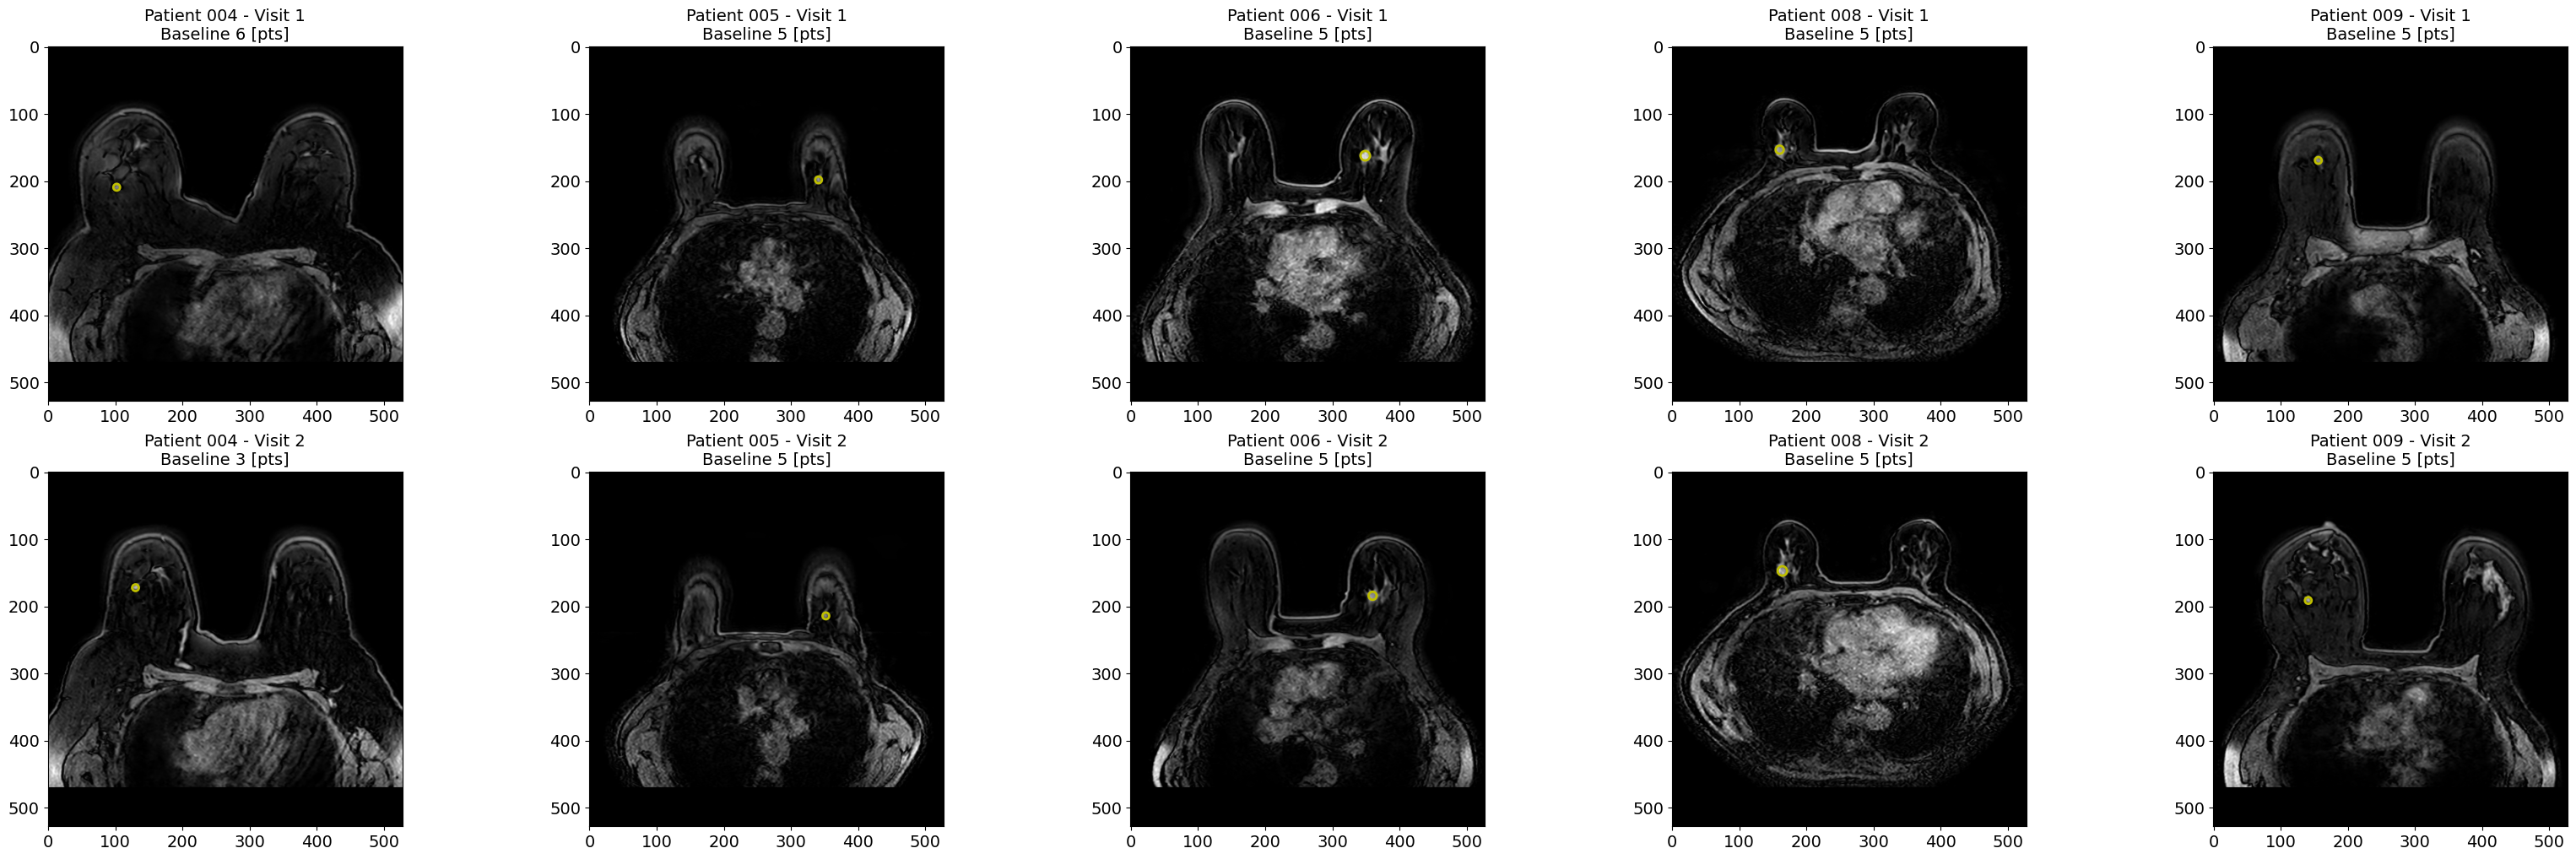

In [ ]:
#TODO: (24/06/2025) Process only patients 004 onwards (not yet implemented the resizing options for patients 001 and 002)
patient_to_process = ['004', '005', '006', '008', '009']
sequence_patterns = ['FA5','FA15','4D','Dyn']

stats_to_retrieve = ['mean','median','std']
preprocessing_status = ['raw','preproc']

t1_dict = {
      'PatientIDnro': [], 
      'PatientID': [], 
      'VisitNro': [], 
      'VisitDate': [],
      'PreProcStatus': [],
      'Anatomy': [],
      'avgT1map': [],
      'stdT1map': [],
      'medT1map': [],
      't1_1d': []
      }

t1_roi_dict = {
      'PatientIDnro': [], 
      'PatientID': [], 
      'VisitNro': [], 
      'VisitDate': [],
      'PreProcStatus': [],
      'Anatomy': [],
      'voxWiseT1': [],
}

for sequence in vfa_sequences:
    for stats in stats_to_retrieve:
            t1_dict['_'.join([sequence, stats])] = []

dyn_htr_dict = {
      'PatientIDnro': [], 
      'PatientID': [], 
      'VisitNro': [], 
      'VisitDate': [],
      'TimeAxis': [],
      'Anatomy': [],
      'ROIstat': [],
      'TR': [],
      'FA': [],
      'BlinePos': [],
      'SignalValue': [],
      'PCenhValue': []
      }

roi_specs = {}
# t1_signal_summary = {}
# dynamic_signal_summary = {}

# For QC purposes, draw the ROI into the pre-contrast Image
[figHeight, figWidth] = [6.0, 8.0]
ncols = len(patient_to_process) # Number of patients 
nrows = 2 # Number of Visits

ca_fig, ca_ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize = (figWidth * ncols, figHeight * nrows))
for patientIdx, patientIDnro in enumerate(patient_to_process):
    patientID = patientsID[patientIDnro]

    print(f'Processing patient {patientID} ({patientIDnro}). Please wait...')
    patient_df = load_patient_data(dicom_dataframe, patientID, sequence_patterns, usePhilipsReScale)
    map_filename_pattern = f'{patientIDnro}_{patientID}'

    weeksBtwn = (patient_df['Visits'][2]['Date'] - patient_df['Visits'][1]['Date']).days
    print('\t- Patient Metadata:')
    print(f'\t\t* Patient ID: {patientID} ')
    print(f'\t\t* Study ID: {patient_df["StudyID"]}')
    print('\t\t* Study Dates: ' + ', '.join([f'{dtime.strftime(visitData["Date"],"%d/%m/%Y")} (Visit {visitIDX})' for visitIDX, visitData in patient_df["Visits"].items()]))
    print(f'\t\t* Weeks Between studies: {weeksBtwn/7:.1f} wks')


    # Load ROI details for patient of interest:
    roi_specs[patientIDnro] = {}
    reference_slice_location = {'tumour': TUMOUR_coord_df.loc[TUMOUR_coord_df['PatientID'] == patientID],
                                'aif': AIF_coord_df.loc[AIF_coord_df['PatientID'] == patientID]
                                }
    # Get the ROI Coordinates by searching for the closes z-location:
    # bbox contains the 4 corners ([xupperleft, yupperlef, xlowerright, ylowerright]) of the bounding box defined from the xoffset and yoffset around the point of interest
    print('\t\t* Getting the ROI Coordinates...')
    for anatomy in anatomies:
        roi_specs[patientIDnro][anatomy] = {}
        for visitNro, visitData in patient_df['Visits'].items():
            ref_coords = reference_slice_location[anatomy][reference_slice_location[anatomy]['StudyDate'].isin([int(visitData['VisitID'])])]
            zlocations = visitData['Sequences']['FA15']['metadata']['SliceMatrix']
            closest_zindex = int(np.argmin(np.abs(zlocations[:,0] - ref_coords['ImagePatientPosZ'].values[0])))
            roi_specs[patientIDnro][anatomy][visitNro] = {'point': ref_coords[['Cx','Cy']].values.flatten().tolist() + [closest_zindex]}
            xoffset = int(np.ceil(ref_coords['Radius'].values[0] / 2))
            yoffset = xoffset
            bbox = [int(np.max([roi_specs[patientIDnro][anatomy][visitNro]['point'][0] - xoffset, 0])), # xupperleft
                    int(np.max([roi_specs[patientIDnro][anatomy][visitNro]['point'][1] - yoffset, 0])), # yupperleft
                    int(roi_specs[patientIDnro][anatomy][visitNro]['point'][0] + xoffset), #xlowerright
                    int(roi_specs[patientIDnro][anatomy][visitNro]['point'][1] + yoffset)  #ylowerright
                    ]
            roi_specs[patientIDnro][anatomy][visitNro]['bbox'] = bbox
            # baseline parameter refers to the length of the baseline, 
            # i.e. the indices for the baseline goes from 0 to baseline-1
            roi_specs[patientIDnro][anatomy][visitNro]['baseline'] = ref_coords['BaseLine'].values[0]
            roi_specs[patientIDnro][anatomy][visitNro]['bbox_radius'] = ref_coords['Radius'].values[0]

            # Create a mask that can be used to get more precise summaries:
            # Get image size reference from the T1W VFA images:
            image_mask = np.zeros_like(visitData['Sequences']['FA5']['nparray'][0,:,:], dtype="uint8")
            cv2.circle(image_mask, ref_coords[['Cx','Cy']].values.flatten().tolist(), ref_coords['Radius'].values[0], [255]*1, -1)
            roi_specs[patientIDnro][anatomy][visitNro]['mask'] = image_mask

    # Get extra Flip Angle data (if the use3FA is TRUE):
    # To use 3 Flip angles, the additional one is created from the dynamic dataset. 
    # Although technically, it can be either the HSR or the HTR, the latter is the selected one, 
    # because the TR, ETL and resolution matches exactly the VFA
    if use3FA:
        print('\t\t* Getting extra Flip Angle data from dynamic dataset...')
        # We do it for both visits:
        for visitNro, visitData in patient_df['Visits'].items():

            thirdFA = visitData['Sequences'][dyn4Ref3FA]['metadata']['FA']
            [nt, ns, w, h] = visitData['Sequences'][dyn4Ref3FA]['nparray'].shape
            thirdFA_nparray = visitData['Sequences'][dyn4Ref3FA]['nparray'][0, :, :, :]
            patient_df['Visits'][visitNro]['Sequences'][f'FA{thirdFA:.0f}'] = {}
            patient_df['Visits'][visitNro]['Sequences'][f'FA{thirdFA:.0f}']['nparray'] = thirdFA_nparray
            patient_df['Visits'][visitNro]['Sequences'][f'FA{thirdFA:.0f}']['metadata'] = {'FA': thirdFA}
            patient_df['Visits'][visitNro]['Sequences'][f'FA{thirdFA:.0f}']['metadata']['TR'] = visitData['Sequences'][dyn4Ref3FA]['metadata']['TR']

            thirdFA_itk = itk.GetImageFromArray(thirdFA_nparray)
            thirdFA_itk.SetSpacing(np.array(visitData['Sequences'][dyn4Ref3FA]['itk'].GetSpacing())[1:])
            thirdFA_itk.SetOrigin(np.array(visitData['Sequences'][dyn4Ref3FA]['itk'].GetOrigin())[1:])
            thirdFA_itk.SetDirection(visitData['Sequences'][dyn4Ref3FA]['metadata']['ITKMetadata']['direction'][:3,:3])
            patient_df['Visits'][visitNro]['Sequences'][f'FA{thirdFA:.0f}']['metadata']['ITKMetadata'] = dict(thirdFA_itk)
            patient_df['Visits'][visitNro]['Sequences'][f'FA{thirdFA:.0f}']['itk'] = thirdFA_itk

            print(f'Image Parameters constructed volume from dynamic series  - Patient {patientID} - Visit {visitNro} ({visitData["Date"]})')
            print(f"\t\t\t ITK Origin: {patient_df['Visits'][visitNro]['Sequences'][f'FA{thirdFA:.0f}']['metadata']['ITKMetadata']['origin']}")
            print(f"\t\t\t ITK Spacing: {patient_df['Visits'][visitNro]['Sequences'][f'FA{thirdFA:.0f}']['metadata']['ITKMetadata']['spacing']}")
            print(f"\t\t\t ITK Direction: {patient_df['Visits'][visitNro]['Sequences'][f'FA{thirdFA:.0f}']['metadata']['ITKMetadata']['direction']}")

    # Apply pre-processing to the data (if the corresponding flags are TRUE):
    for visitNro, visitData in patient_df['Visits'].items():
        for sequence in vfa_sequences:
            volume_to_process = itk.image_duplicator(visitData['Sequences'][sequence]['itk'])
            if noiseRedFiltFlag & ( noiseRedMethod is not None ):
                print(f'\t\t\t Applying noise reduction ({noiseRedMethod.capitalize()}) filter')
                if noiseRedMethod == 'median':
                    volume_to_process = itk.median_image_filter(volume_to_process, Radius=radius)

                elif noiseRedMethod == 'gaussian':
                    volume_to_process = itk.discrete_gaussian_image_filter(volume_to_process, variance=gvar)

            if biasFlag:
                print('\t\t\t Applying NT4K bias correction field')
                volume_to_process = nt4k_bias_correction(volume_to_process)

            if regFlag:
                if not ( sequence == fixed_sequence_flag ):
                    print(f'\t\t\t Registering dataset {sequence} to {fixed_sequence_flag}')
                    volume_to_process, result_transform_parameters = itk.elastix_registration_method(
                        visitData['Sequences'][fixed_sequence_flag]['itk'], 
                        volume_to_process, 
                        parameter_object=parameter_object, log_to_console=False)
            patient_df['Visits'][visitNro]['Sequences'][sequence]['nparray_proc'] = itk.GetArrayFromImage(volume_to_process)

    # Calculate voxe-wise T1 fit (for now, only if 2 Flip angles to use the rational approximation)
    # NOTE we use both RAW and PROCESSED volumes (nparray & nparray_proc)
    print('\t\t* Calculating voxel-wise T1 fit ...')
    for visitNro, visitData in patient_df['Visits'].items():
        flip_angles = [visitData['Sequences']['FA5']['metadata']['FA'],
                       visitData['Sequences']['FA15']['metadata']['FA']
                       ]
        repetition_time = [visitData['Sequences']['FA5']['metadata']['TR'],
                           visitData['Sequences']['FA15']['metadata']['TR']
                           ]
        preproc_image_data  =  [visitData['Sequences']['FA5']['nparray_proc'],
                                visitData['Sequences']['FA15']['nparray_proc']
                                ]
        raw_image_data  =  [visitData['Sequences']['FA5']['nparray'],
                            visitData['Sequences']['FA15']['nparray']
                            ]

        if use3FA:
            flip_angles.append(visitData['Sequences']['FA10']['metadata']['FA'])
            repetition_time.append(visitData['Sequences']['FA10']['metadata']['TR'])
            preproc_image_data.append(visitData['Sequences']['FA10']['nparray_proc'])
            raw_image_data.append(visitData['Sequences']['FA10']['nparray'])
        
        print(f'Calculating the T1 map (simple Linear fit) for patient {patientID}, visit {visitNro}.\nPlease wait...')
        T1map_raw, M0map_raw = t1fit_vfa(raw_image_data, flip_angles,
                                {'TR': np.median(repetition_time),
                                },
                                FitAlgo = fit_algorithm, T1ub=T1ub, T1lb=T1lb)
        T1map_preproc, M0map_preproc = t1fit_vfa(preproc_image_data, flip_angles,
                                {'TR': np.median(repetition_time),
                                },
                                FitAlgo = fit_algorithm, T1ub=T1ub, T1lb=T1lb)

        if smoothFlag:
            print('\t\t\t Smoothing Output maps')
            T1map_raw = itk.median_image_filter(T1map_raw, Radius=1)
            M0map_raw = itk.median_image_filter(M0map_raw, Radius=1)
            T1map_preproc = itk.median_image_filter(T1map_preproc, Radius=1)
            M0map_preproc = itk.median_image_filter(M0map_preproc, Radius=1)
            
        patient_df['Visits'][visitNro]['T1map_raw'] = T1map_raw
        patient_df['Visits'][visitNro]['M0map_raw'] = M0map_raw
        patient_df['Visits'][visitNro]['T1map_preproc'] = T1map_preproc
        patient_df['Visits'][visitNro]['M0map_preproc'] = M0map_preproc
        patient_df['Visits'][visitNro]['T1method'] = fit_algorithm
    

    # Summarise ROI signal intensities from all sequences, get mean, std and median:
    # Here, I have to loop over the sequences and visit to extract the ROI, also consider the pre-processed and raw data:
    print('\t\t* Extracting ROI stats T1W acquisitions and voxel-wise T1maps ...')
    for visitNro, visitData in patient_df['Visits'].items():
        # Simultaneously extract the dynamic data from the HTR Dynamic sequence:
        htr_dce_nparray = visitData['Sequences']['4D']['nparray']
        [nt, ns, h, w] = htr_dce_nparray.shape
        time_domain = visitData['Sequences']['4D']['metadata']['TimeMatrix']

        for anatomy in anatomies:
            mask = roi_specs[patientIDnro][anatomy][visitNro]['mask']
            [x, y, z] = roi_specs[patientIDnro][anatomy][visitNro]['point']
            radius = roi_specs[patientIDnro][anatomy][visitNro]['bbox_radius']

            # Process the dynamic dataset
            time_axis = time_domain[z, :]
            nt = len(time_axis)
            time_axis -= time_axis[0]
            # baseline_stop = roi_specs[patientIDnro][anatomy][visitNro]['baseline']
            # baseline_stop = 5
            baseline_stop = roi_specs[patientIDnro]['aif'][visitNro]['baseline']
            # patient_df['Visits'][visitNro]['DCE'][anatomy]['time_sec'] = time_axis
            # Equivalent uniform time axis:
            dt = np.median(np.diff(time_axis[1:]))
            time_axis = np.linspace(0.0, dt * nt, num=nt, endpoint=False)
            # patient_df['Visits'][visitNro]['DCE'][anatomy]['dt'] = dt
            # patient_df['Visits'][visitNro]['DCE'][anatomy]['norm_time_sec'] = time_axis

            # For QC purposes display the pre-contrast image showing the tumour ROI slice:
            if anatomy == 'tumour':
                ca_ax[visitNro - 1, patientIdx].imshow(htr_dce_nparray[0, z, :, :], cmap='gray')
                circle = plt.Circle((x, y), radius, color='y', fill=False, linewidth = 2)
                ca_ax[visitNro - 1, patientIdx].add_artist(circle)
                ca_ax[visitNro - 1, patientIdx].set_title(f'Patient {patientIDnro} - Visit {visitNro}\nBaseline {baseline_stop} [pts]')

            median_signal = np.zeros_like(time_axis)
            std_signal = np.zeros_like(time_axis)
            median_signal = np.zeros_like(time_axis)

            baseline_roi = np.median(htr_dce_nparray[:baseline_stop, z, :, :], axis=0)
            baseline_roi_mask = baseline_roi[mask > 0]
            baseline_signal = np.mean(baseline_roi_mask)

            aux_signal = np.zeros((len(time_axis), len(baseline_roi_mask)))
            for tpoint in range(len(time_axis)):
                signal_slice = htr_dce_nparray[tpoint, z, :, :].copy()

                signal_roi = signal_slice[mask > 0]
                pcenh_roi  = signal_roi - baseline_roi_mask
                pcenh_roi *= 100 / baseline_roi_mask

                for stats in stats_to_retrieve:
                    dyn_htr_dict['PatientIDnro'].append(patientIDnro)
                    dyn_htr_dict['PatientID'].append(patientID)
                    dyn_htr_dict['VisitNro'].append(visitNro)
                    dyn_htr_dict['VisitDate'].append(visitData['VisitID'])
                    dyn_htr_dict['TimeAxis'].append(time_axis[tpoint])
                    dyn_htr_dict['Anatomy'].append(anatomy)
                    dyn_htr_dict['ROIstat'].append(stats)
                    dyn_htr_dict['BlinePos'].append(baseline_stop)
                    dyn_htr_dict['TR'].append(visitData['Sequences']['4D']['metadata']['TR'])
                    dyn_htr_dict['FA'].append(visitData['Sequences']['4D']['metadata']['FA'])
                    if stats == 'mean':
                        dyn_htr_dict['SignalValue'].append(np.mean( signal_roi ))
                        dyn_htr_dict['PCenhValue'].append(np.mean( pcenh_roi ))
                    elif stats == 'median':
                        dyn_htr_dict['SignalValue'].append(np.median( signal_roi ))
                        dyn_htr_dict['PCenhValue'].append(np.median( pcenh_roi ))
                    elif stats == 'std':
                        dyn_htr_dict['SignalValue'].append(np.std( signal_roi ))
                        dyn_htr_dict['PCenhValue'].append(np.std( pcenh_roi ))
                    else:
                        print(f'[WARNING]: Stats {stats} not recognised')

            for preproc, preprocstatus in zip(preprocessing_status, ['nparray','nparray_proc']):
                t1_dict['PatientID'].append(patientID)
                t1_dict['PatientIDnro'].append(patientIDnro)
                t1_dict['VisitNro'].append(visitNro)
                t1_dict['VisitDate'].append(visitData['VisitID'])
                t1_dict['PreProcStatus'].append(preproc)
                t1_dict['Anatomy'].append(anatomy)

                # gets the T1 VFA maps
                T1map_slice = visitData[f'T1map_{preproc}'][z, :, :]
                T1map_roi = T1map_slice[mask > 0]
                t1_mean, t1_std, t1_median = [np.nanmean(T1map_roi), np.nanstd(T1map_roi), np.nanmedian(T1map_roi)]
                t1_dict['avgT1map'].append(t1_mean)
                t1_dict['stdT1map'].append(t1_std)
                t1_dict['medT1map'].append(t1_median)
                tr = []
                fa = []
                t1wsi = []

                # Voxel-Wise T1 map
                t1_roi_dict['PatientID'].append(patientID) 
                t1_roi_dict['PatientIDnro'].append(patientIDnro)
                t1_roi_dict['VisitNro'].append(visitNro)  
                t1_roi_dict['VisitDate'].append(visitData['VisitID']) 
                t1_roi_dict['PreProcStatus'].append(preproc) 
                t1_roi_dict['Anatomy'].append(anatomy) 
                t1_roi_dict['voxWiseT1'].append(T1map_roi)

                for sequence in vfa_sequences:
                    seq_slice = patient_df['Visits'][visitNro]['Sequences'][sequence][preprocstatus][z, :, :]
                    seq_roi = seq_slice[mask > 0]
                    si_mean, si_std, si_median = [np.nanmean(seq_roi), np.nanstd(seq_roi), np.nanmedian(seq_roi)]
                    t1_dict['_'.join([sequence, 'mean'])].append(si_mean)
                    t1_dict['_'.join([sequence, 'std'])].append(si_std)
                    t1_dict['_'.join([sequence, 'median'])].append(si_median)
                    # To calculate T1 from median ROI:
                    fa.append(visitData['Sequences'][sequence]['metadata']['FA'])
                    tr.append(visitData['Sequences'][sequence]['metadata']['TR'])
                    t1wsi.append(si_median)

                t1_1d, m0_1d = t1fit_vfa(t1wsi, flip_angles,
                                {'TR': np.median(tr),
                                },
                                FitAlgo = fit_algorithm, T1ub=T1ub, T1lb=T1lb)
                t1_dict['t1_1d'].append(t1_1d)


# Build up the dataframes for t1 and dynamic (Force the PatientIDnro to be string)
t1_df = pd.DataFrame.from_dict(t1_dict)
t1_df['PatientIDnro'].astype('str')
t1_roi_df = pd.DataFrame.from_dict(t1_roi_dict)
t1_roi_df['PatientIDnro'].astype('str')
dyn_df = pd.DataFrame.from_dict(dyn_htr_dict)
dyn_df['PatientIDnro'].astype('str')

# Save the dataframe as CSV
t1_df.to_csv(os.path.join(OUTPUT, 't1_vfa.csv'), index=True, index_label='IndexKey')
dyn_df.to_csv(os.path.join(OUTPUT, 'htr_dyn.csv'), index=True, index_label='IndexKey')


# Use the dataframe to test PK modelling options

In [326]:
## Give the option to read the dataframe externally from the CSV:
# t1_path_to_csv  = os.path.join(OUTPUT, 't1_vfa.csv')
# dyn_path_to_csv = os.path.join(OUTPUT, 'htr_dyn.csv')
# t1_df  = pd.read_csv(t1_path_to_csv, index_col='IndexKey')
# dyn_df = pd.read_csv(dyn_path_to_csv)


In [327]:
print("".join(["*"]*50))
print('* Displays Dataframes:')
print("".join(["*"]*50))
print('T1 data:')
print("".join(["-"]*10))
display(t1_df.head())
print('Dyn data:')
print("".join(["-"]*10))
display(dyn_df.head())
print(f'{"".join(["*"]*50)}')


**************************************************
* Displays Dataframes:
**************************************************
T1 data:
----------


,PatientIDnro,PatientID,VisitNro,VisitDate,PreProcStatus,Anatomy,avgT1map,stdT1map,medT1map,t1_1d,FA5_mean,FA5_median,FA5_std,FA15_mean,FA15_median,FA15_std
0,004,ANON44148,1,20230405,raw,tumour,552.034970,330.570263,448.887012,463.813089,46915.148823,49236.355469,10540.226618,46260.531334,48695.296875,14153.142889
1,004,ANON44148,1,20230405,preproc,tumour,552.034970,330.570263,448.887012,463.813089,46915.148823,49236.355469,10540.226618,46260.531334,48695.296875,14153.142889
2,004,ANON44148,1,20230405,raw,aif,966.763146,804.722842,703.121511,769.999143,22048.576166,22453.943359,5021.374031,16992.149320,17313.882812,7313.291438
3,004,ANON44148,1,20230405,preproc,aif,966.763146,804.722842,703.121511,769.999143,22048.576166,22453.943359,5021.374031,16992.149320,17313.882812,7313.291438
4,004,ANON44148,2,20230511,raw,tumour,511.263371,472.906230,335.837469,387.514204,46879.095534,48352.250000,16499.052018,50638.775795,52310.910156,21576.305875


Dyn data:
----------


,PatientIDnro,PatientID,VisitNro,VisitDate,TimeAxis,Anatomy,ROIstat,TR,FA,BlinePos,SignalValue,PCenhValue
0,004,ANON44148,1,20230405,0.000,tumour,mean,5.1824,10.0,6,52787.403549,-0.029772
1,004,ANON44148,1,20230405,0.000,tumour,median,5.1824,10.0,6,55438.660156,0.000000
2,004,ANON44148,1,20230405,0.000,tumour,std,5.1824,10.0,6,14018.473129,1.875815
3,004,ANON44148,1,20230405,3.595,tumour,mean,5.1824,10.0,6,53450.218461,1.286552
4,004,ANON44148,1,20230405,3.595,tumour,median,5.1824,10.0,6,56022.226562,1.086952


**************************************************


## QC: Plot Dynamic data

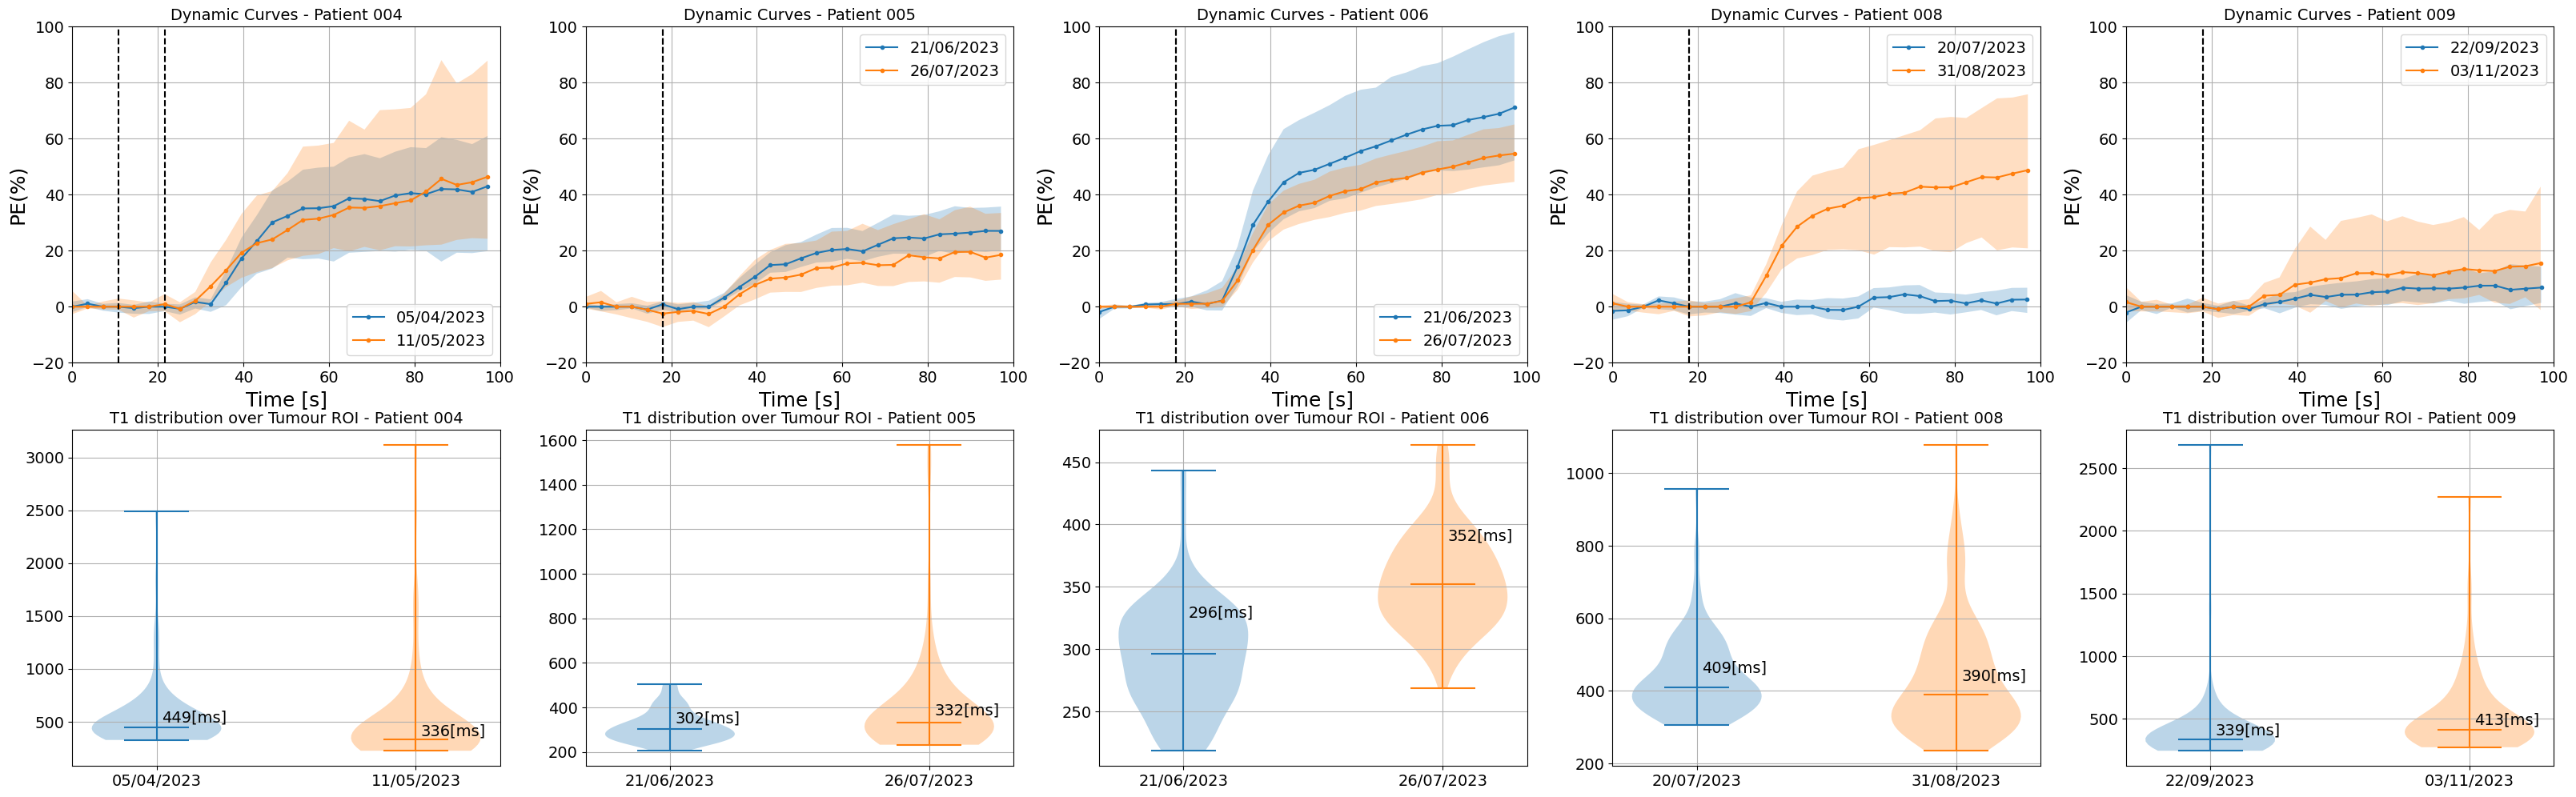

In [ ]:
# Setup filters to select data
dyn_df_filter_dict = {
    # 'PatientIDnro': ['004'],
    'Anatomy': ['tumour'],
    'ROIstat': ['mean', 'median', 'std']
    }

# Apply isin for each column in df_mask and combine with &
dyn_df_mask = pd.Series(True, index=dyn_df.index)
for col, values in dyn_df_filter_dict.items():
    dyn_df_mask &= dyn_df[col].isin(values)

sub_dyn_df = dyn_df[dyn_df_mask]

# The same but for T1:
t1_df_filter_dict = {
    # 'PatientIDnro': dyn_df_filter_dict['PatientIDnro'],
    'Anatomy': dyn_df_filter_dict['Anatomy'],
    'PreProcStatus': ['preproc']
    }
t1_df_mask = pd.Series(True, index=t1_roi_df.index)
for col, values in t1_df_filter_dict.items():
    t1_df_mask &= t1_roi_df[col].isin(values)

sub_t1_df = t1_roi_df[t1_df_mask]

fields_to_plot = {
    'x': 'TimeAxis', 
    'y': 'PCenhValue'
    }

nrows, ncols = [2, len(sub_dyn_df['PatientIDnro'].unique())]
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=( fig_width * ncols, fig_height * nrows ))
axr = ax.ravel()

for patientIdx, patient in enumerate(sub_dyn_df['PatientIDnro'].unique()):
    
    patient_data_df = sub_dyn_df[sub_dyn_df['PatientIDnro'].isin([patient])].copy()
    t10_patient = sub_t1_df[sub_t1_df['PatientIDnro'].isin([patient])].copy()

    for (visit, dyn_curves), (t1visit, t1_vals) in zip(patient_data_df.groupby(['VisitDate']), t10_patient.groupby(['VisitDate'])):

        # Median Signal is the median over the ROI for each time point (I think this is the correct way)
        median_signal = dyn_curves[dyn_curves['ROIstat'].isin(['median'])]

        # To display the variability interval, I use the mean ± std, which can be related to an "interval of agreement"
        mean_signal = dyn_curves[dyn_curves['ROIstat'].isin(['mean'])]
        std_signal = dyn_curves[dyn_curves['ROIstat'].isin(['std'])]

        # Plot the central tendency (each time point is the MEDIAN over the ROI)
        top_row = patientIdx
        bottom_row = ncols + patientIdx
        avg_line = median_signal.plot(ax=axr[top_row], 
                                    x=fields_to_plot['x'], y=fields_to_plot['y'], 
                                    marker='.', 
                                    label=dtime.strftime(dtime.strptime(visit[0],'%Y%m%d'), '%d/%m/%Y'))
        clr_line = avg_line.lines[-1].get_color()

        # Interval of agreement mean ± std:
        upper_band = mean_signal[fields_to_plot['y']].values + std_signal[fields_to_plot['y']].values
        lower_band = mean_signal[fields_to_plot['y']].values - std_signal[fields_to_plot['y']].values

        # Plot the baseline
        axr[ top_row ].plot([dyn_curves[fields_to_plot['x']].unique()[dyn_curves['BlinePos'].unique()]]*2, [-20, 100], 'k--')

        axr[ top_row ].fill_between(dyn_curves[fields_to_plot['x']].unique(),
                                       upper_band, lower_band,
                                       facecolor=clr_line,
                                       alpha=0.25, interpolate=True, label='StdDev over ROI')
        
        # Display T1 ROI values
        voxWiseT1 = t1_vals['voxWiseT1'].values[0]
        voxWiseT1 = voxWiseT1[~np.isnan(voxWiseT1)]
        axr[ bottom_row ].violinplot(voxWiseT1, t1_vals['VisitNro'].values-1, showmeans=False, showmedians=True)
        axr[ bottom_row ].text(t1_vals['VisitNro'].values-0.98, np.median(voxWiseT1)*(1.1), f'{np.median(voxWiseT1):.0f}[ms]')

    axr[ top_row ].set_xlabel('Time [s]')
    axr[ top_row ].set_ylabel('PE(%)')
    axr[ top_row ].grid(True)
    axr[ top_row ].axis([0, 100, -20, 100])
    axr[ top_row ].set_title(f'Dynamic Curves - Patient {patient}')

    xticks = []
    xlabels = []
    for idx, visit in enumerate(t10_patient['VisitDate'].unique()):
        xticks.append(idx)
        xlabels.append(dtime.strftime(dtime.strptime(visit,'%Y%m%d'), '%d/%m/%Y'))
    axr[ bottom_row ].grid(True)
    axr[ bottom_row ].set_xticks(xticks, labels=xlabels)
    axr[ bottom_row ].set_title(f'T1 distribution over Tumour ROI - Patient {patient}')

# fig.suptitle(f'Patient {dyn_df_filter_dict["PatientIDnro"][0]} - {dyn_df_filter_dict["Anatomy"][0].capitalize()} ROI')


# Ready to start testing DCMRI options...

# DCEMRI Quantitative Analysis

In [354]:
# Relaxivities at 1.5T & 37C (see Table above)
relaxivities = {'magnevist': 4.1,
                'multihance': 6.3,
                'omniscan': 4.3,
                'dotarem': 3.6,
                'prohance': 4.1, 
                'gadavist': 5.2,
                'eovist': 6.9,
                'vueway': 12.8 
                }

ca_family = 'gadobutrol'
ca_name = 'gadavist'
r1 = relaxivities[ca_name]
r1_dcmri = dcmri.relaxivity(1.5, agent=ca_family)
print(f'Relaxivity of CA: {r1}[L/(mmol*s)]')
print(f'Relaxivity of CA (DCMRI): {r1_dcmri}[Hz/M]')

# Reference T1:
reference_t1 = {
    'tumour': 876.0, #ms
    'aif': 1441.0, #ms
    }


Relaxivity of CA: 5.2[L/(mmol*s)]
Relaxivity of CA (DCMRI): 5200.0[Hz/M]


Here we process all dataset, or can select individual patients, but in any case, it takes the whole dataframes created when loading the data

In [361]:
# Get the correction factor, from T1 group averages:
correct_t10 = True

ref_t1_filter_criteria = {
    'PreProcStatus': ['preproc'],
    # 'VisitNro': [2]
    }

# Apply isin for each column in df_mask and combine with &
df_mask = pd.Series(True, index=t1_df.index)
for col, values in ref_t1_filter_criteria.items():
    df_mask &= t1_df[col].isin(values)

t1_ref_sub_df = t1_df[df_mask]

# Option 1: Median T1 over the ROI (medT1map field in t1_df)
stats_t10 = 't1_1d'
avg_t1_calc = t1_ref_sub_df.groupby(by=['Anatomy']).describe()[stats_t10]['mean']

t1_correction_factor = {}
for refAnatomy, refT1 in reference_t1.items():
    t1_correction_factor[refAnatomy] =  refT1 / avg_t1_calc[refAnatomy]

t1_correction_factor


{'tumour': np.float64(2.3614962675129725),
 'aif': np.float64(2.113048999204267)}

In [444]:
# Start with individual data, and then implement a loop over the cohort
dyn_df_filter_dict = {
    # 'PatientIDnro': ['004'],
    'Anatomy': ['tumour'],
    'ROIstat': ['median']
    }

# Apply isin for each column in df_mask and combine with &
dyn_df_mask = pd.Series(True, index=dyn_df.index)
for col, values in dyn_df_filter_dict.items():
    dyn_df_mask &= dyn_df[col].isin(values)

dyn_fields_to_remove = ['PCenhValue']
sub_dyn_df = dyn_df[dyn_df_mask].drop(columns=dyn_fields_to_remove)
display(sub_dyn_df.head())

# The same but for T1:
t1_df_filter_dict = {
    # 'PatientIDnro': dyn_df_filter_dict['PatientIDnro'],
    'PreProcStatus': ['preproc']
    }

t1_df_mask = pd.Series(True, index=t1_df.index)
for col, values in t1_df_filter_dict.items():
    t1_df_mask &= t1_df[col].isin(values)

t1_fields_to_remove = ['avgT1map', 'stdT1map', 'FA5_mean','FA5_median','FA5_std','FA15_mean','FA15_median','FA15_std']
sub_t1_df = t1_df[t1_df_mask].drop(columns=t1_fields_to_remove)
display(sub_t1_df.head())


,PatientIDnro,PatientID,VisitNro,VisitDate,TimeAxis,Anatomy,ROIstat,TR,FA,BlinePos,SignalValue
1,004,ANON44148,1,20230405,0.000,tumour,median,5.1824,10.0,6,55438.660156
4,004,ANON44148,1,20230405,3.595,tumour,median,5.1824,10.0,6,56022.226562
7,004,ANON44148,1,20230405,7.190,tumour,median,5.1824,10.0,6,55438.660156
10,004,ANON44148,1,20230405,10.785,tumour,median,5.1824,10.0,6,54855.097656
13,004,ANON44148,1,20230405,14.380,tumour,median,5.1824,10.0,6,54855.097656


,PatientIDnro,PatientID,VisitNro,VisitDate,PreProcStatus,Anatomy,medT1map,t1_1d
1,004,ANON44148,1,20230405,preproc,tumour,448.887012,463.813089
3,004,ANON44148,1,20230405,preproc,aif,703.121511,769.999143
5,004,ANON44148,2,20230511,preproc,tumour,335.837469,387.514204
7,004,ANON44148,2,20230511,preproc,aif,600.839919,694.789191
9,005,ANON93295,1,20230621,preproc,tumour,302.254583,310.409263


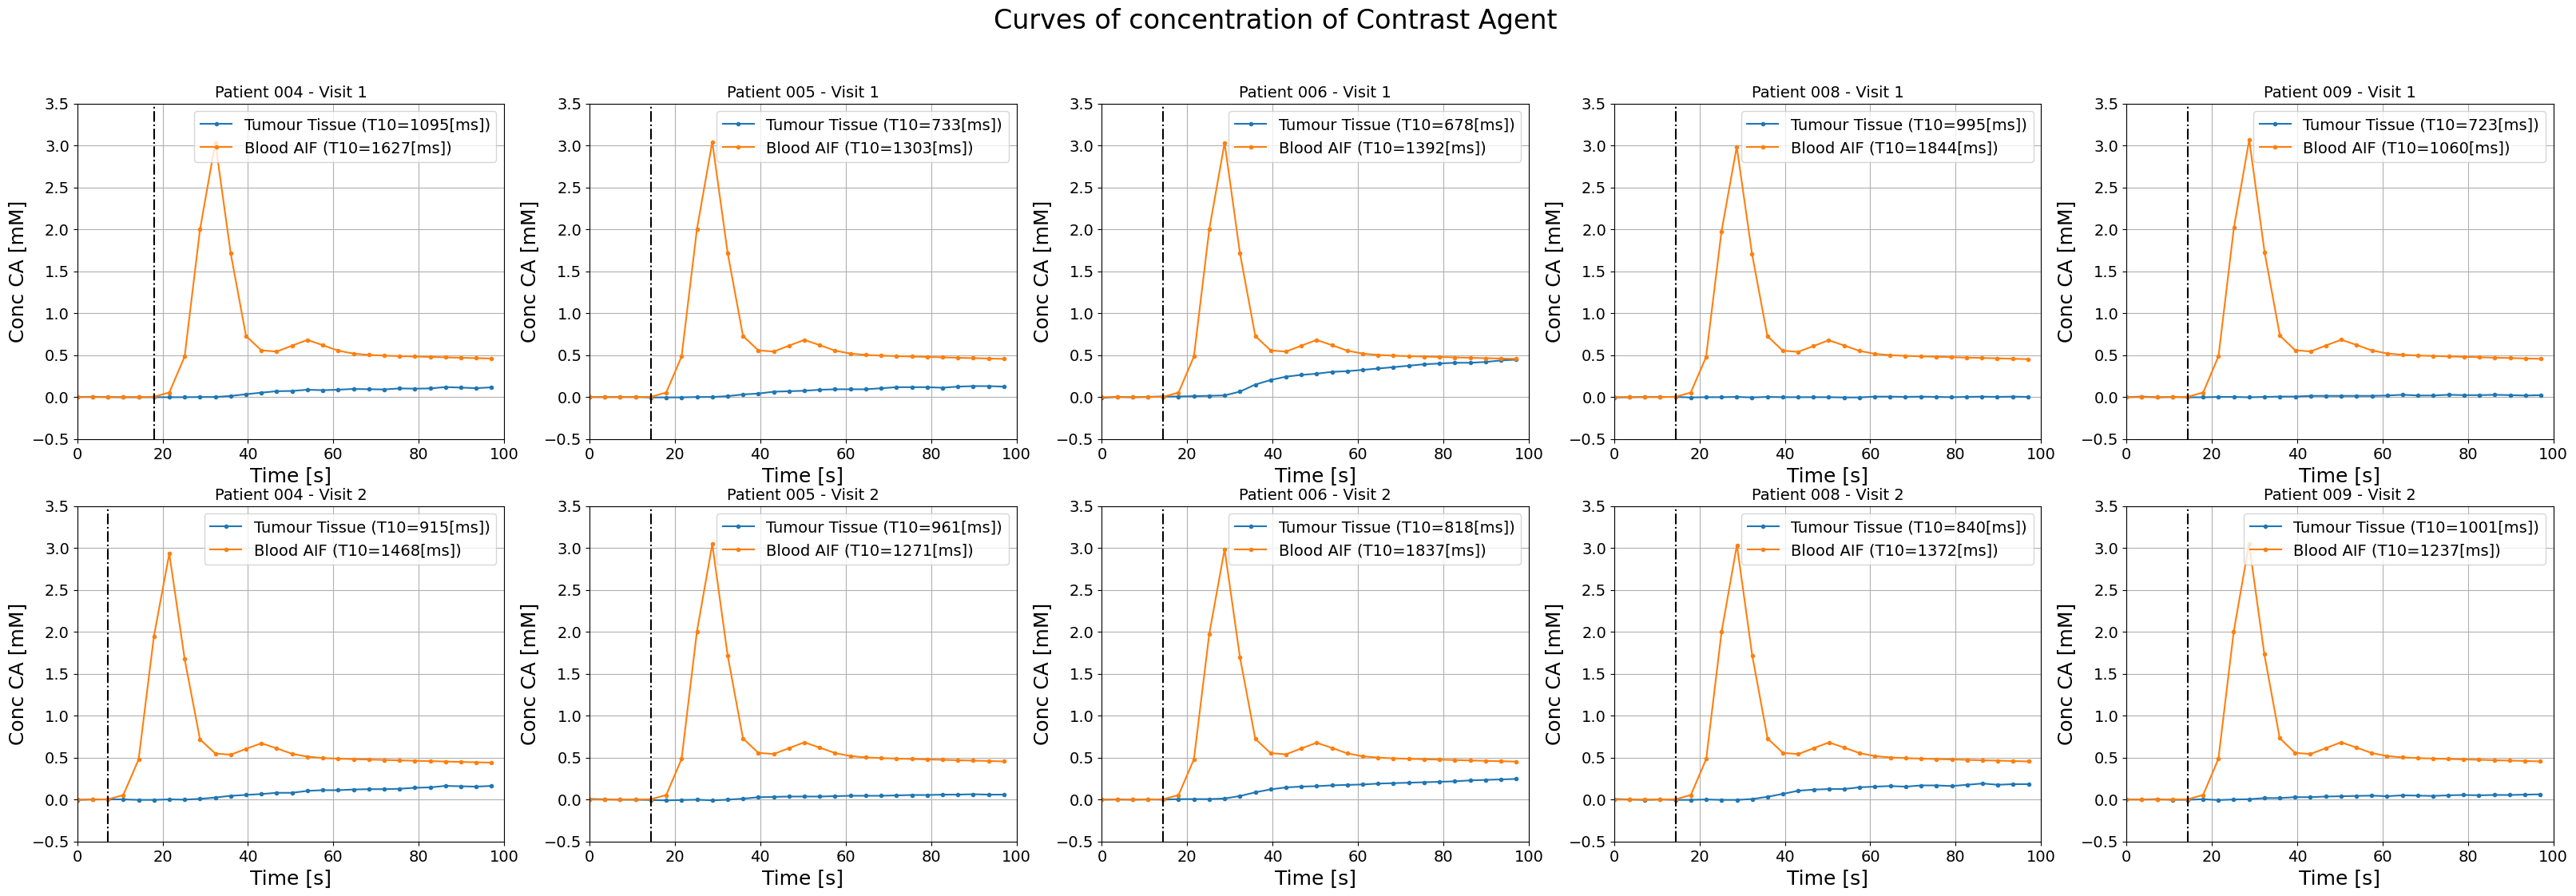

In [601]:
# PK parameters
pk_kinetics = 'WV'
water_exchange = 'FF'

# Loop over patients
nrows, ncols = [2, len(sub_dyn_df['PatientIDnro'].unique())]

ca_fig, ca_ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=( fig_width * ncols, fig_height * nrows ))
ca_axr = ca_ax.ravel()

pk_model = {}
pk_results = {'Patient': [],
              'VisitNro': [],
              'VisitDate': [],
              'KTrans': [],
              'T10': []}

for patientIdx, patient in enumerate(sub_dyn_df['PatientIDnro'].unique()):
    
    patient_data_df = sub_dyn_df[sub_dyn_df['PatientIDnro'].isin([patient])].copy()
    t10_patient = sub_t1_df[sub_t1_df['PatientIDnro'].isin([patient])].copy()
    pk_model[patient] = {}

    for visit in patient_data_df['VisitNro'].unique():
        visit_in_patient_subdf = patient_data_df[patient_data_df['VisitNro'].isin([visit])].copy()
        t10_patient_visit = t10_patient[t10_patient['VisitNro'].isin([visit])].copy()

        if correct_t10:
            for anatomy in t10_patient_visit['Anatomy'].unique():
                t10_patient_visit.loc[t10_patient_visit['Anatomy'].isin([anatomy]), stats_t10] *= t1_correction_factor[anatomy]
        # display(t10_patient_visit)
        
        # PK parameters:
        dynTR = visit_in_patient_subdf['TR'].unique()[0] / 1000.0
        dynFA = int(visit_in_patient_subdf['FA'].unique()[0])
        t10 = t10_patient_visit[t10_patient_visit['Anatomy'].isin(['tumour'])][stats_t10].values[0] / 1000.0
        t10blood = t10_patient_visit[t10_patient_visit['Anatomy'].isin(['aif'])][stats_t10].values[0] / 1000.0
        # print(f'Dynamic TR:\t{dynTR:.3f} s')
        # print(f'Dynamic FA:\t{dynFA:.1f} deg')
        # print(f'Baseline T1:\t{t10:.3f} s')
        n0 = visit_in_patient_subdf['BlinePos'].unique()[0]
        time_axis = visit_in_patient_subdf['TimeAxis'].values
        dyn_signal = visit_in_patient_subdf['SignalValue'].values
        dyn_bline = np.mean(dyn_signal[:n0])
        # dyn_signal -= dyn_bline

        pk_model[patient][f'visit{visit}'] = {'T10': t10,
                                                'T10blood': t10blood,
                                                'TR': dynTR,
                                                'FA': dynFA,
                                                'N0': n0,
                                                'TimeAxis': time_axis
                                                }

        # AIF:
        syn_time, syn_aif, syn_gt = dcmri.fake_aif(tacq = time_axis[ -1 ] + time_axis[ 1 ],
                                                    dt = time_axis[ 1 ],
                                                    BAT = time_axis[ n0 ],
                                                    field_strength = 1.5,
                                                    agent = ca_family,
                                                    R10a = 1.0 / t10blood,
                                                    S0 = dyn_bline,
                                                    model='SS',
                                                    TR=dynTR,
                                                    FA=dynFA
                                                    )

        ct_tissue = 1000.0 * dcmri.conc_ss(dyn_signal, dynTR, dynFA, t10, r1=r1_dcmri, n0=n0)
        ct_aif = 1000.0 * dcmri.conc_ss(syn_aif, dynTR, dynFA, t10blood, r1 = r1_dcmri, n0=n0)

        pk_model[patient][f'visit{visit}']['ct_tumor'] = ct_tissue
        pk_model[patient][f'visit{visit}']['ct_aif'] = ct_aif
        
        pk_model[patient][f'visit{visit}']['model'] = dcmri.Tissue(
            kinetics = pk_kinetics,
            water_exchange=water_exchange,
            ca = ct_aif / 1000.0, # mM -> M
            t = time_axis,
            r1 = r1_dcmri,
            R10 = 1.0 / t10,
            R10a = 1.0 / t10blood,
            TR = dynTR,
            FA = dynFA,
            n0 = n0,
            # B1corr=1.0
            )

        pk_model[patient][f'visit{visit}']['model'].train(time_axis, dyn_signal)

        if ( pk_kinetics == 'WV' ):
            pk_results['T10'].append(t10)
            pk_results['KTrans'].append(pk_model[patient][f'visit{visit}']['model'].export_params()['Ktrans'][1]*60*1000)
            pk_results['Patient'].append(patient)
            pk_results['VisitNro'].append(visit)
            pk_results['VisitDate'].append(visit_in_patient_subdf['VisitDate'].unique()[0])

        fig_index = ncols * ( visit - 1 ) + patientIdx 

        ca_axr[ fig_index ].plot(time_axis, ct_tissue, '.-', label=f'Tumour Tissue (T10={t10*1000:.0f}[ms])')
        ca_axr[ fig_index ].plot(time_axis, ct_aif, '.-', label=f'Blood AIF (T10={t10blood*1000:.0f}[ms])')
        ca_axr[ fig_index ].set_title(f'Patient {patient} - Visit {visit}')
        ca_axr[ fig_index ].set_xlabel('Time [s]')
        ca_axr[ fig_index ].set_ylabel('Conc CA [mM]')
        ca_axr[ fig_index ].grid(True)
        ca_axr[ fig_index ].legend(loc='upper right')
        ca_axr[ fig_index ].axis([0.0, np.max([time_axis[ -1 ], 100]), -0.5, 3.5])
        ca_axr[ fig_index ].plot( [time_axis[ n0 - 1 ]]*2, [ -0.5, 3.5 ], 'k-.')

_ = ca_fig.suptitle('Curves of concentration of Contrast Agent')

pk_results_df = pd.DataFrame.from_dict(pk_results)


# Comparison with Histopathology

In [ ]:
# Load histopath file:
histopath_excel_path = os.path.join(HISTPATH, 'QualAnalysis_AQ_2122023_v1_df_format.xlsx')
hist_sheet = 'DataFrame'

histopath_df = pd.read_excel(histopath_excel_path, sheet_name=hist_sheet)
# Ensure PatientNro's type is string:
histopath_df['Patient'] = histopath_df['Patient'].astype(str).str.zfill(3)
# histopath_df.drop(index=[0,1,2,3], inplace=True)
histopath_df.head()

# Combine pk_results_df with histopath_df:
cohort_results = pd.merge(pk_results_df, histopath_df, on=['Patient', 'VisitNro'])

# Pivot so each VisitNro becomes a column and summarise as the difference in Ktrans:
pivoted = cohort_results.pivot(index='Patient', columns='VisitNro', values=['KTrans', 'Category'])
# Calculate the difference: VisitNro 2 - VisitNro 1
pivoted['KTrans_diff'] = pivoted['KTrans'][2] - pivoted['KTrans'][1]
pivoted['Groups'] = pivoted['Category'][1]
# pivoted.drop(columns=['KTrans', 'Category'], inplace=True)

# If you want to merge this back to the original dataframe:
# cohort_results = cohort_results.merge(
#     pivoted['KTrans_diff'], left_on='Patient', right_index=True
# )
# Remove 'VisitNro' from the index
# pivoted = pivoted.reset_index(level='VisitNro', drop=True)
#
pivoted


KTrans             Category     KTrans_diff Groups
VisitNro           1           2        1   2                   
Patient                                                         
004        68.583189   79.194316       NR  NR   10.611127     NR
005          72.4192   33.090427        R   R  -39.328773      R
006       271.839761  146.601636        R   R -125.238125      R
008         1.017753  109.391167       NR  NR  108.373414     NR
009         13.45537   33.400093       NR  NR   19.944724     NR

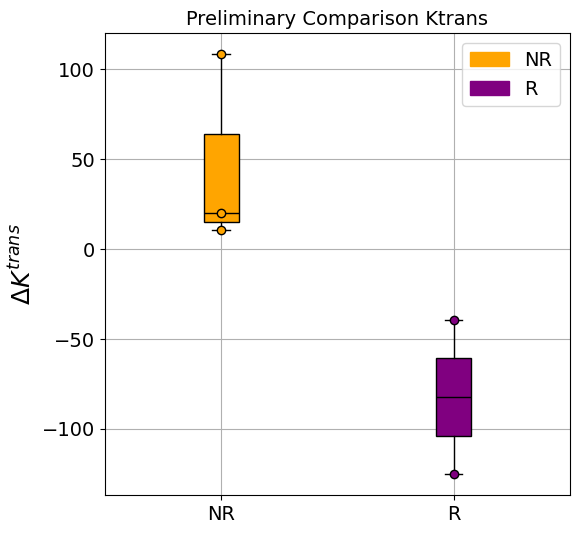

In [ ]:
# Plot paired Ktrans

# Init a figure and axes
fig, ax = plt.subplots(figsize=(6, 6))

grouped = pivoted.groupby('Groups')['KTrans_diff']
parameter_per_visits = [group.values for name, group in grouped]
# Create the plot with different colors for each group
boxplot = ax.boxplot(x = parameter_per_visits,
                     tick_labels=grouped.groups.keys(),
                     patch_artist=True,
                     medianprops={'color': 'black'},
                    )

# Define colors for each group
colours = ['orange', 'purple']

# Assign colors to each box in the boxplot
for box, colour in zip(boxplot['boxes'], colours):
    box.set_facecolor(colour)

# Scatter plot: plot each point at the correct x position
for i, (group, colour) in enumerate(zip(parameter_per_visits, colours), start=1):
    ax.scatter(
        [i] * len(group),  # x positions
        group,             # y values
        color=colour,
        edgecolor='black',
        zorder=3
    )
    # ax.text([i] * len(group),
    #         group,
            
    #         )
# Set x-tick labels
ax.set_xticks(range(1, len(grouped.groups.keys()) + 1))
ax.set_xticklabels(grouped.groups.keys())
 

# Create a legend for the groups
legend_labels = pivoted['Groups'].unique()
legend_handles = [plt.Rectangle((0,0),1,1, color=colour) for colour in colours]
ax.legend(legend_handles, legend_labels)
ax.set_title('Preliminary Comparison Ktrans')
ax.set_ylabel(r'$\Delta K^{trans}$')
ax.grid(True)


In [ ]:
grouped
